# Simulated Samples Mueller Matrix PR Test with M11 Normalization
# ================================================================

This notebook tests XGBoost, MLP, and CatBoost models on simulated Mueller matrix samples
with proper M11 normalization. Tests three simulated samples: 225µm, 250µm, and 300µm.
Each sample is normalized by M[0,0] (M11 element) before PR testing.


In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# ML libraries
import xgboost as xgb
from catboost import CatBoostClassifier
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Add project root to path (adjust as needed for your setup)
# Try different possible project root locations
possible_roots = [
    Path().cwd().parent.parent.resolve(),  # Original attempt
    Path().cwd().parent.resolve(),         # One level up
    Path().cwd().resolve(),                # Current directory
    Path(__file__).parent.parent.resolve() if '__file__' in globals() else None,  # Script location
]

project_root = None
for root in possible_roots:
    if root and (root / 'src').exists():
        project_root = root
        break

if project_root:
    sys.path.insert(0, str(project_root))
    print(f"Found project root at: {project_root}")
else:
    print("Could not find project root with 'src' directory.")
    print("Current working directory:", Path().cwd())
    print("Please manually set the project_root variable to your project directory")

# Import your utilities (adjust import paths as needed)
try:
    from src.utils.file_paths import file_paths, TISSUE_DIMENSIONS
    from src.utils.pr_test import charpoly, charpoly_vectorized
    from src.utils.visualisation import visualize_save_mueller
    UTILITIES_AVAILABLE = True
    print("Successfully imported utilities")
except ImportError as e:
    print(f"Could not import utilities: {e}")
    print("You may need to:")
    print("1. Adjust the project_root path above")
    print("2. Or run this from the correct directory")
    print("3. Or manually set sys.path to include your project root")
    UTILITIES_AVAILABLE = False

# Try to use faster BLAS if available
try:
    import mkl
    mkl.set_num_threads(1)  # Prevent oversubscription in parallel operations
except ImportError:
    pass

Found project root at: /Users/chaechae/Desktop/EP_Code/partialPr
Successfully imported utilities


In [2]:
class PixelMLP(nn.Module):
    """MLP model for pixel classification - matches saved model with BatchNorm"""
    def __init__(self, input_dim=12, hidden_dims=[128, 64, 32], dropout_rate=0.2):
        super(PixelMLP, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            # Linear layer
            layers.append(nn.Linear(prev_dim, hidden_dim))
            # BatchNorm layer
            layers.append(nn.BatchNorm1d(hidden_dim))
            # ReLU activation
            layers.append(nn.ReLU())
            # Dropout
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim

        # Output layer
        layers.append(nn.Linear(prev_dim, 1))

        # Use 'net' to match saved model
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [3]:
def load_simulated_sample(sample_name):
    """
    Load a simulated sample file (H,W,16) from the simulated test directory
    
    Args:
        sample_name: Name of the sample file (e.g., 'mm_225um_raw.npy')
        
    Returns:
        arr: Loaded array (H, W, 16)
        dims: Dimensions info
    """
    print(f"Loading simulated sample: {sample_name}")

    test_dir = file_paths.simulated_test_path
    dims = TISSUE_DIMENSIONS['simulated']

    # Find the sample file
    sample_path = test_dir / sample_name
    if not sample_path.exists():
        # Try to find it in subdirectories
        found_files = list(test_dir.glob(f'**/{sample_name}'))
        if found_files:
            sample_path = found_files[0]
        else:
            raise FileNotFoundError(f"Sample not found: {sample_name} in {test_dir}")

    # Load the sample
    arr = np.load(sample_path)
    expected_shape = (dims['num_rows'], dims['num_cols'], 16)

    print(f"Loaded sample shape: {arr.shape}")
    print(f"Expected shape: {expected_shape}")

    if arr.shape != expected_shape:
        print(f"Warning: Shape mismatch!")

    return arr, dims

In [4]:
def mueller_matrix_to_dataframe(mueller_matrix):
    """
    Convert Mueller matrix array (H, W, 16) to DataFrame format expected by visualize_save_mueller
    
    Args:
        mueller_matrix: Array of shape (H, W, 16)
        
    Returns:
        df: DataFrame with shape (H*W, 16) where each row is a flattened pixel
    """
    H, W, _ = mueller_matrix.shape
    # Reshape to (H*W, 16) - each row is a pixel with 16 Mueller elements
    reshaped = mueller_matrix.reshape(-1, 16)
    
    # Create DataFrame with column names M00, M01, ..., M33 (or just indices)
    df = pd.DataFrame(reshaped)
    
    return df

In [ ]:
def normalize_mueller_matrix_by_m11(mueller_matrix):
    """Normalize a *simulated* Mueller matrix for PR testing.

    IMPORTANT — convention of the simulated .npy files:
    The polarized Monte Carlo output stores the 15 non-M11 elements ALREADY
    normalized by M11 (each |m_ij| <= 1), while the [0,0] slot holds the raw
    backscattered reflectance (~1e-9), NOT the value 1. A real Mueller matrix
    must have M11 as its largest element; here M11 is ~1e7x smaller than the
    other elements, which is the tell-tale sign the data is already normalized.

    Therefore the correct operation is to SET M11 = 1 (Option B), keeping the
    other 15 already-normalized elements as-is. Dividing every element by the
    tiny raw M11 again (the previous behaviour) double-normalizes the matrix,
    blowing the elements up to ~1e6 and making every signal pixel fail the PR
    test. (For *experimental* data, where M11 is the true intensity, ordinary
    division by M11 remains correct - this helper is for the simulated data.)

    Args:
        mueller_matrix: Mueller matrix array (H, W, 16), simulated convention.

    Returns:
        normalized_matrix: Normalized Mueller matrix (H, W, 16) with M11 = 1.
        normalization_stats: Statistics about the normalization.
    """
    print("Normalizing simulated Mueller matrix (Option B: set M11 = 1)...")

    H, W, _ = mueller_matrix.shape

    # Raw [0,0] slot (stored reflectance) - reported for diagnostics only.
    m11_values = mueller_matrix[:, :, 0]
    m11_stats = {
        'min': np.min(m11_values),
        'max': np.max(m11_values),
        'mean': np.mean(m11_values),
        'std': np.std(m11_values),
        'median': np.median(m11_values),
        'zero_count': int(np.sum(m11_values == 0)),
        'negative_count': int(np.sum(m11_values < 0)),
    }
    print("Raw [0,0] slot statistics (stored reflectance, expected << other elements):")
    print(f"  Min: {m11_stats['min']:.3e}  Max: {m11_stats['max']:.3e}  Mean: {m11_stats['mean']:.3e}")
    off = np.abs(mueller_matrix.reshape(-1, 16)[:, 1:])
    print(f"  Max |non-M11 element| = {off.max():.4f}  (already-normalized data has this <= 1)")

    # Sanity check: warn if the data looks like a RAW matrix (M11 is the largest
    # element), in which case Option B would be the wrong choice.
    if np.nanmax(np.abs(m11_values)) >= off.max():
        print("  WARNING: M11 appears to be the largest element - this looks like RAW data.")
        print("           Option B (set M11=1) may be inappropriate; verify the convention.")

    # Option B: keep the already-normalized 15 elements, set M11 to 1.
    normalized_matrix = mueller_matrix.copy().astype(float)
    normalized_matrix[:, :, 0] = 1.0

    normalized_m11 = normalized_matrix[:, :, 0]
    normalization_check = {
        'normalized_m11_min': float(np.min(normalized_m11)),
        'normalized_m11_max': float(np.max(normalized_m11)),
        'normalized_m11_mean': float(np.mean(normalized_m11)),
        'normalized_m11_std': float(np.std(normalized_m11)),
    }
    print("[OK] M11 set to 1.0 for all pixels; remaining elements left unchanged.")

    normalization_stats = {
        'original_m11_stats': m11_stats,
        'normalization_check': normalization_check,
        'total_pixels': H * W,
        'successfully_normalized': int(np.sum(np.abs(normalized_m11 - 1.0) < 1e-10)),
    }

    return normalized_matrix, normalization_stats


In [6]:
def compute_ground_truth_pr_mask(mueller_matrix, batch_size=50000):
    """
    Compute ground truth PR mask using vectorized charpoly method
    
    Args:
        mueller_matrix: Mueller matrix array (H, W, 16)
        batch_size: Number of pixels to process per batch
        
    Returns:
        pr_mask: Boolean mask (H, W) indicating physically realizable pixels
        timing_info: Timing information
    """
    print(f"Computing ground truth PR test using vectorized charpoly (batch size: {batch_size:,})...")
    
    H, W, _ = mueller_matrix.shape
    total_pixels = H * W
    
    # Pre-reshape to (N, 4, 4) for batch processing
    mueller_matrices = mueller_matrix.reshape(-1, 16).reshape(-1, 4, 4)
    pr_results = np.zeros(total_pixels, dtype=bool)
    
    start_time = time.perf_counter()
    
    # Process in batches using vectorized operations
    for i in range(0, total_pixels, batch_size):
        end_idx = min(i + batch_size, total_pixels)
        batch_matrices = mueller_matrices[i:end_idx]
        
        # Vectorized PR test - processes entire batch at once
        batch_results = charpoly_vectorized(batch_matrices)
        pr_results[i:end_idx] = batch_results
    
    end_time = time.perf_counter()
    gt_time_s = end_time - start_time
    gt_time_ms = gt_time_s * 1000
    
    # Reshape back to (H, W)
    pr_mask = pr_results.reshape(H, W)
    pr_pixels = np.sum(pr_mask)
    
    print(f"Ground truth PR test completed in {gt_time_ms:.2f} ms ({gt_time_s:.3f}s)")
    print(f"GT PR pixels: {pr_pixels:,} ({pr_pixels/total_pixels*100:.2f}%)")
    
    timing_info = {
        'time': gt_time_s,
        'time_ms': gt_time_ms,
        'samples_per_second': total_pixels / gt_time_s,
        'samples_per_ms': total_pixels / gt_time_ms,
        'total_pixels': total_pixels,
        'pr_pixels': int(pr_pixels),
        'batch_size': batch_size
    }
    
    return pr_mask, timing_info

In [7]:
def predict_mlp(model, X, batch_size=4096, device=None):
    """Generate predictions using MLP model with batching"""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            preds.append(probs)
    return np.concatenate(preds)

In [8]:
def load_and_predict_ml(mueller_matrix, use_model='xgb', scenario='3x4', batch_size=None, threshold=0.5):
    """
    Load an ML model and make predictions for a specific feature scenario.

    Args:
        mueller_matrix: Mueller matrix array (H, W, 16)
        use_model: ML model to use ('xgb', 'mlp', 'cat')
        scenario: Feature scenario ('3x3', '3x4', '4x3')
        batch_size: Batch size for processing
        threshold: Probability threshold for classification

    Returns:
        ml_mask: Predicted PR mask (H, W)
        timing_info: Timing information
    """
    H, W, _ = mueller_matrix.shape
    total_pixels = H * W

    scenario = scenario.lower()
    scenario_cfg = {
        '3x3': {
            'xgb': 'pixel_xgb_3x3.json',
            'mlp': 'best_pixel_mlp_3x3.pth',
            'cat': 'pixel_catboost_3x3.cbm',
            'selector': lambda M: M[:, :, :3, :3],
        },
        '3x4': {
            'xgb': 'pixel_xgb.json',
            'mlp': 'best_pixel_mlp.pth',
            'cat': 'pixel_catboost.cbm',
            'selector': lambda M: M[:, :, :3, :],
        },
        '4x3': {
            'xgb': 'pixel_xgb_4x3.json',
            'mlp': 'best_pixel_mlp_4x3.pth',
            'cat': 'pixel_catboost_4x3.cbm',
            'selector': lambda M: M[:, :, :, :3],
        },
    }

    if scenario not in scenario_cfg:
        raise ValueError(f"Invalid scenario: {scenario}. Use one of ['3x3', '3x4', '4x3']")

    M44 = mueller_matrix.reshape(H, W, 4, 4)
    X_flat = scenario_cfg[scenario]['selector'](M44).reshape(total_pixels, -1)
    feature_dim = X_flat.shape[1]

    # Device for PyTorch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if use_model.lower() == 'xgb':
        print(f"Making XGBoost predictions for {scenario} (threshold: {threshold})...")
        print(f"Using {feature_dim} Mueller matrix elements for XGBoost")

        dmat = xgb.DMatrix(X_flat, nthread=1)
        xgb_model = xgb.Booster()
        xgb_model.load_model(str(file_paths.model_save_path / scenario_cfg[scenario]['xgb']))

        start_time = time.perf_counter()
        probs = xgb_model.predict(dmat)
        end_time = time.perf_counter()
        ml_mask = (probs > threshold).reshape(H, W)

    elif use_model.lower() == 'mlp':
        print(f"Making MLP predictions for {scenario} (batch_size: {batch_size if batch_size else 'default'}, threshold: {threshold})...")
        print(f"Using {feature_dim} Mueller matrix elements")

        torch.set_num_threads(1)  # prevent OpenMP deadlock in Jupyter on macOS
        mlp = PixelMLP(input_dim=feature_dim).to(device)
        mlp_path = file_paths.model_save_path / scenario_cfg[scenario]['mlp']
        mlp.load_state_dict(torch.load(mlp_path, map_location=device, weights_only=False))
        mlp.eval()

        mlp_batch_size = batch_size if batch_size is not None else 4096

        start_time = time.perf_counter()
        probs = predict_mlp(mlp, X_flat, batch_size=mlp_batch_size, device=device)
        end_time = time.perf_counter()
        ml_mask = (probs > threshold).reshape(H, W)

    elif use_model.lower() == 'cat':
        print(f"Making CatBoost predictions for {scenario} (threshold: {threshold})...")
        print(f"Using {feature_dim} Mueller matrix elements")

        cat_model = CatBoostClassifier()
        cat_model.load_model(str(file_paths.model_save_path / scenario_cfg[scenario]['cat']))

        start_time = time.perf_counter()
        probs = cat_model.predict_proba(X_flat)[:, 1]
        end_time = time.perf_counter()
        ml_mask = (probs > threshold).reshape(H, W)

    else:
        raise ValueError(f"Invalid model type: {use_model}")

    ml_time_s = end_time - start_time
    ml_time_ms = ml_time_s * 1000
    ml_pixels = np.sum(ml_mask)

    print(f"{use_model.upper()} ({scenario}) completed in {ml_time_ms:.2f} ms ({ml_time_s:.4f}s)")
    print(f"ML PR pixels: {ml_pixels:,} ({ml_pixels / total_pixels * 100:.2f}%)")

    timing_info = {
        'model': use_model.lower(),
        'scenario': scenario,
        'feature_dim': int(feature_dim),
        'time': ml_time_s,
        'time_ms': ml_time_ms,
        'samples_per_second': total_pixels / ml_time_s,
        'samples_per_ms': total_pixels / ml_time_ms,
        'total_pixels': total_pixels,
        'pr_pixels': int(ml_pixels),
        'batch_size': batch_size if use_model.lower() == 'mlp' else total_pixels,
        'threshold': threshold
    }

    return ml_mask, timing_info


In [9]:
def compare_methods(gt_mask, ml_mask, model_name):
    """
    Compare ground truth and ML predictions
    
    Args:
        gt_mask: Ground truth PR mask (H, W)
        ml_mask: ML predicted PR mask (H, W)
        model_name: Name of the ML model
        
    Returns:
        comparison_metrics: Dictionary with comparison metrics
    """
    print(f"Comparing {model_name} with ground truth...")

    # Calculate confusion matrix elements
    true_positives = np.sum(gt_mask & ml_mask)
    false_positives = np.sum(~gt_mask & ml_mask)
    false_negatives = np.sum(gt_mask & ~ml_mask)
    true_negatives = np.sum(~gt_mask & ~ml_mask)

    total_pixels = gt_mask.size

    # Calculate metrics
    accuracy = (true_positives + true_negatives) / total_pixels
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Agreement statistics
    agreement = np.sum(gt_mask == ml_mask) / total_pixels

    # Jaccard index (Intersection over Union)
    intersection = np.sum(gt_mask & ml_mask)
    union = np.sum(gt_mask | ml_mask)
    jaccard = intersection / union if union > 0 else 0

    comparison_metrics = {
        'model': model_name,
        'total_pixels': total_pixels,
        'gt_pr_pixels': int(np.sum(gt_mask)),
        'ml_pr_pixels': int(np.sum(ml_mask)),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'agreement': agreement,
        'jaccard_index': jaccard
    }

    print("Comparison Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  Agreement: {agreement:.4f} ({agreement * 100:.2f}%)")
    print(f"  Jaccard Index: {jaccard:.4f}")

    return comparison_metrics


In [10]:
def visualize_comparison(gt_mask, ml_masks, model_names, sample_name, normalization_stats=None):
    """
    Visualize comparison between ground truth and ML models
    Shows only physically realizable pixels (True values) in orange (publication color coding)
    
    Args:
        gt_mask: Ground truth PR mask (H, W) - True for physically realizable
        ml_masks: List of ML predicted PR masks - True for physically realizable
        model_names: List of model names
        sample_name: Name of the sample
        normalization_stats: M11 normalization statistics
    """
    CMAP_MASK = mcolors.LinearSegmentedColormap.from_list("pr_warm", ["black", "#E06030"])
    print("Creating comparison visualization (showing only PR pixels)...")
    
    n_models = len(ml_masks)
    fig, axes = plt.subplots(2, n_models + 1, figsize=(5 * (n_models + 1), 10))
    
    if n_models == 1:
        axes = axes.reshape(2, -1)
    
    # Ground truth (top row, first column)
    # Invert mask pixels for display to match publication convention
    axes[0, 0].imshow(1 - gt_mask.astype(np.uint8), cmap=CMAP_MASK, vmin=0, vmax=1)
    gt_pr_count = np.sum(gt_mask)
    gt_total = gt_mask.size
    axes[0, 0].set_title(f'Ground Truth\n(Vectorized charpoly)\nPR: {gt_pr_count:,} ({gt_pr_count/gt_total*100:.1f}%)')
    axes[0, 0].axis('off')
    
    # ML models (top row, remaining columns)
    for i, (ml_mask, model_name) in enumerate(zip(ml_masks, model_names)):
        # Invert mask pixels for display to match publication convention
        axes[0, i + 1].imshow(1 - ml_mask.astype(np.uint8), cmap=CMAP_MASK, vmin=0, vmax=1)
        ml_pr_count = np.sum(ml_mask)
        ml_total = ml_mask.size
        axes[0, i + 1].set_title(f'{model_name}\nPrediction\nPR: {ml_pr_count:,} ({ml_pr_count/ml_total*100:.1f}%)')
        axes[0, i + 1].axis('off')
    
    # Difference maps (bottom row)
    axes[1, 0].axis('off')  # Empty space below ground truth
    
    for i, (ml_mask, model_name) in enumerate(zip(ml_masks, model_names)):
        # Calculate difference: 
        # +1 (red): GT says PR, ML says non-PR (False Negative)
        # -1 (blue): GT says non-PR, ML says PR (False Positive) 
        #  0 (white): Agreement
        diff = gt_mask.astype(int) - ml_mask.astype(int)
        
        # Count disagreements
        false_negatives = np.sum((gt_mask == True) & (ml_mask == False))  # GT=PR, ML=non-PR
        false_positives = np.sum((gt_mask == False) & (ml_mask == True))   # GT=non-PR, ML=PR
        agreement = np.sum(gt_mask == ml_mask)
        
        im = axes[1, i + 1].imshow(diff, cmap='RdBu_r', vmin=-1, vmax=1)
        axes[1, i + 1].set_title(''
        )
        axes[1, i + 1].axis('off')
        
        # Add colorbar with labels
        cbar = plt.colorbar(im, ax=axes[1, i + 1], shrink=0.6)
        cbar.set_ticks([-1, 0, 1])
        cbar.set_ticklabels(['FP (ML>GT)', 'Agreement', 'FN (GT>ML)'])
    
    # Add normalization info to title if available
    title = f'Simulated Sample PR Test: {sample_name}'
    if normalization_stats:
        title += f'\n(M11 Normalized - {normalization_stats["successfully_normalized"]}/{normalization_stats["total_pixels"]} pixels)'
    title += '\nOrange = Physically Realizable, Black = Non-Realizable'
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
def run_simulated_sample_test(sample_name, models=['xgb', 'mlp', 'cat'], scenarios=['3x3', '3x4', '4x3'], 
                             gt_batch_size=50000, ml_batch_size=100000, threshold=0.5):
    """
    Run PR test on a single simulated sample with M11 normalization.

    Args:
        sample_name: Name of the simulated sample
        models: List of models to test
        scenarios: Feature scenarios to test ('3x3', '3x4', '4x3')
        gt_batch_size: Batch size for ground truth processing
        ml_batch_size: Batch size for ML model processing
        threshold: Probability threshold for ML classification
    """
    print("=" * 80)
    print(f"SIMULATED SAMPLE PR TEST: {sample_name}")
    print("=" * 80)

    try:
        # 1. Load the simulated sample
        mueller_matrix, dims = load_simulated_sample(sample_name)

        print(f"Sample: {sample_name}")
        print(f"Original shape: {mueller_matrix.shape}")
        print(f"Total pixels: {mueller_matrix.shape[0] * mueller_matrix.shape[1]:,}")
        print("-" * 80)

        # 2. Normalize by M11
        print("Step 1: M11 Normalization")
        normalized_matrix, norm_stats = normalize_mueller_matrix_by_m11(mueller_matrix)
        print("-" * 80)

        H, W, _ = mueller_matrix.shape
        cols = [f"M{i}{j}" for i in range(1, 5) for j in range(1, 5)]
        out_dir = file_paths.figures / "simulated"
        out_dir.mkdir(parents=True, exist_ok=True)

        # 2b. Visualize with background masked (exact-zero M11 pixels set to NaN).
        raw_vis = mueller_matrix.copy().astype(float)
        raw_vis[raw_vis[:, :, 0] == 0] = np.nan
        df_masked = pd.DataFrame(raw_vis.reshape(-1, 16), columns=cols)

        visualize_save_mueller(
            data=df_masked,
            visualisation_path=out_dir,
            sample_number=sample_name,
            wavelength="sim",
            label="Normalized",
            num_rows=H,
            num_cols=W,
            filter_zeros=False,
            crop_square=False,
            show_fig=False,
            diagonal_range=(-0.2, 0.2),
            offdiagonal_range=(-0.02, 0.02),
        )

        # 2c. Visualize without any filtering — all pixels shown as-is.
        df_raw = pd.DataFrame(mueller_matrix.reshape(-1, 16), columns=cols)

        visualize_save_mueller(
            data=df_raw,
            visualisation_path=out_dir,
            sample_number=sample_name,
            wavelength="sim",
            label="NoFilter",
            num_rows=H,
            num_cols=W,
            filter_zeros=False,
            crop_square=False,
            show_fig=False,
            diagonal_range=(-0.2, 0.2),
            offdiagonal_range=(-0.02, 0.02),
        )

        # 3. Compute ground truth PR mask on normalized data
        print("Step 2: Ground Truth PR Test")
        gt_mask, gt_timing = compute_ground_truth_pr_mask(normalized_matrix, batch_size=gt_batch_size)
        print("-" * 80)

        # 4. Test each ML model across each scenario
        ml_results = {}
        step_counter = 1

        for scenario in scenarios:
            print(f"\n--- Scenario: {scenario} ---")
            scenario_masks = []
            scenario_model_names = []

            for model in models:
                print(f"Step 3.{step_counter}: Testing {model.upper()} ({scenario})")
                step_counter += 1
                try:
                    if model.lower() == 'mlp':
                        ml_mask, ml_timing = load_and_predict_ml(
                            normalized_matrix,
                            use_model=model,
                            scenario=scenario,
                            batch_size=ml_batch_size,
                            threshold=threshold,
                        )
                    else:
                        ml_mask, ml_timing = load_and_predict_ml(
                            normalized_matrix,
                            use_model=model,
                            scenario=scenario,
                            batch_size=None,
                            threshold=threshold,
                        )

                    display_name = f"{model.upper()} ({scenario})"
                    comparison_metrics = compare_methods(gt_mask, ml_mask, display_name)

                    result_key = f"{scenario}_{model.lower()}"
                    ml_results[result_key] = {
                        'timing': ml_timing,
                        'comparison': comparison_metrics,
                        'mask': ml_mask,
                        'model': model.lower(),
                        'scenario': scenario,
                    }

                    scenario_masks.append(ml_mask)
                    scenario_model_names.append(display_name)

                except Exception as e:
                    print(f"Error testing {model.upper()} ({scenario}): {e}")
                    import traceback
                    traceback.print_exc()
                    continue
                print("-" * 40)

            # One visualization per scenario (keeps plots readable)
            if scenario_masks:
                visualize_comparison(
                    gt_mask,
                    scenario_masks,
                    scenario_model_names,
                    f"{sample_name} [{scenario}]",
                    norm_stats,
                )

        # 5. Print comprehensive summary
        print("\n" + "=" * 80)
        print(f"SIMULATED SAMPLE RESULTS SUMMARY: {sample_name}")
        print("=" * 80)

        print(f"M11 Normalization Results:")
        print(f"  Total pixels: {norm_stats['total_pixels']:,}")
        print(f"  Successfully normalized: {norm_stats['successfully_normalized']:,}")
        print(f"  Original M11 mean: {norm_stats['original_m11_stats']['mean']:.6f}")
        print(f"  Original M11 std: {norm_stats['original_m11_stats']['std']:.6f}")
        print(f"  Zero M11 values: {norm_stats['original_m11_stats']['zero_count']}")
        print(f"  Negative M11 values: {norm_stats['original_m11_stats']['negative_count']}")
        print()

        print(f"Ground Truth (Vectorized charpoly):")
        print(f"  Time: {gt_timing['time_ms']:.2f} ms ({gt_timing['time']:.3f}s)")
        print(f"  Speed: {gt_timing['samples_per_second']:,.1f} samples/s")
        print(f"  PR Pixels: {gt_timing['pr_pixels']:,} ({gt_timing['pr_pixels']/gt_timing['total_pixels']*100:.2f}%)")
        print()

        for key, results in ml_results.items():
            timing = results['timing']
            comparison = results['comparison']
            speed_ratio = timing['samples_per_second'] / gt_timing['samples_per_second']
            time_ratio = gt_timing['time_ms'] / timing['time_ms']

            display_name = f"{results['model'].upper()} ({results['scenario']})"
            print(f"{display_name}:")
            print(f"  Time: {timing['time_ms']:.2f} ms ({timing['time']:.3f}s)")
            print(f"  Speed: {timing['samples_per_second']:,.1f} samples/s")
            print(f"  Speed Ratio (ML/GT): {speed_ratio:.1f}x")
            print(f"  Time Ratio (GT/ML): {time_ratio:.1f}x")
            print(f"  PR Pixels: {timing['pr_pixels']:,} ({timing['pr_pixels']/timing['total_pixels']*100:.2f}%)")
            print(f"  Accuracy: {comparison['accuracy']:.4f}")
            print(f"  F1 Score: {comparison['f1_score']:.4f}")
            print(f"  Precision: {comparison['precision']:.4f}")
            print(f"  Recall: {comparison['recall']:.4f}")
            print()

        return {
            'sample_name': sample_name,
            'normalization_stats': norm_stats,
            'ground_truth': gt_timing,
            'ml_results': ml_results,
            'config': {
                'scenarios': scenarios,
                'gt_batch_size': gt_batch_size,
                'ml_batch_size': ml_batch_size,
                'threshold': threshold,
            }
        }

    except Exception as e:
        print(f"Error during simulated sample test: {e}")
        import traceback
        traceback.print_exc()
        return None


In [12]:
def run_all_simulated_samples_test(sample_names=['mm_225um_raw.npy', 'mm_250um_raw.npy', 'mm_300um_raw.npy'],
                                  models=['xgb', 'mlp', 'cat'],
                                  scenarios=['3x3', '3x4', '4x3'],
                                  gt_batch_size=50000, ml_batch_size=100000, threshold=0.5):
    """
    Run PR tests on all simulated samples.

    Args:
        sample_names: List of simulated sample names
        models: List of models to test
        scenarios: Feature scenarios to test ('3x3', '3x4', '4x3')
        gt_batch_size: Batch size for ground truth processing
        ml_batch_size: Batch size for ML model processing
        threshold: Probability threshold for ML classification
    """
    print("=" * 100)
    print("COMPREHENSIVE SIMULATED SAMPLES PR TEST")
    print("Testing multiple simulated samples with M11 normalization")
    print(f"Scenarios: {', '.join(scenarios)}")
    print("=" * 100)

    all_results = {}

    for sample_name in sample_names:
        print(f"\n{'='*20} TESTING {sample_name} {'='*20}")

        try:
            result = run_simulated_sample_test(
                sample_name=sample_name,
                models=models,
                scenarios=scenarios,
                gt_batch_size=gt_batch_size,
                ml_batch_size=ml_batch_size,
                threshold=threshold,
            )

            if result:
                all_results[sample_name] = result
                print(f"✓ Successfully completed {sample_name}")
            else:
                print(f"✗ Failed to process {sample_name}")

        except Exception as e:
            print(f"✗ Error processing {sample_name}: {e}")
            continue

    # Create summary comparison across all samples
    if all_results:
        print("\n" + "=" * 100)
        print("CROSS-SAMPLE COMPARISON SUMMARY")
        print("=" * 100)

        # Create summary table
        summary_data = []

        for sample_name, result in all_results.items():
            thickness = sample_name.split('_')[1]  # e.g., '225um' from 'mm_225um_raw.npy'

            gt_stats = result['ground_truth']
            norm_stats = result['normalization_stats']

            base_row = {
                'Sample': thickness,
                'Total_Pixels': gt_stats['total_pixels'],
                'GT_Time_ms': gt_stats['time_ms'],
                'GT_PR_Pixels': gt_stats['pr_pixels'],
                'GT_PR_Percent': gt_stats['pr_pixels'] / gt_stats['total_pixels'] * 100,
                'M11_Mean_Original': norm_stats['original_m11_stats']['mean'],
                'M11_Std_Original': norm_stats['original_m11_stats']['std'],
                'Zero_M11_Count': norm_stats['original_m11_stats']['zero_count'],
            }

            for result_key, ml_result in result['ml_results'].items():
                row = base_row.copy()
                row.update({
                    'Scenario': ml_result['scenario'],
                    'Model': ml_result['model'].upper(),
                    'Model_Key': result_key.upper(),
                    'ML_Time_ms': ml_result['timing']['time_ms'],
                    'ML_PR_Pixels': ml_result['timing']['pr_pixels'],
                    'ML_PR_Percent': ml_result['timing']['pr_pixels'] / ml_result['timing']['total_pixels'] * 100,
                    'Accuracy': ml_result['comparison']['accuracy'],
                    'F1_Score': ml_result['comparison']['f1_score'],
                    'Precision': ml_result['comparison']['precision'],
                    'Recall': ml_result['comparison']['recall'],
                    'Speed_Ratio': ml_result['timing']['samples_per_second'] / gt_stats['samples_per_second'],
                })
                summary_data.append(row)

        try:
            import pandas as pd
            df = pd.DataFrame(summary_data)
            print("\nDetailed Results Table:")
            print(df.to_string(index=False, float_format='%.4f'))
        except ImportError:
            print("\nDetailed Results:")
            for row in summary_data:
                print(f"Sample: {row['Sample']}, Scenario: {row['Scenario']}, Model: {row['Model']}")
                print(f"  GT Time: {row['GT_Time_ms']:.2f}ms, ML Time: {row['ML_Time_ms']:.2f}ms")
                print(f"  Accuracy: {row['Accuracy']:.4f}, F1: {row['F1_Score']:.4f}")
                print(f"  Speed Ratio: {row['Speed_Ratio']:.2f}x")
                print()

        # Find best performing (scenario,model) combos across samples
        model_keys_tested = set()
        for result in all_results.values():
            model_keys_tested.update(result['ml_results'].keys())

        print(f"\nCross-Sample Model Performance:")
        for model_key in sorted(model_keys_tested):
            model_results = []
            for sample_name, result in all_results.items():
                if model_key in result['ml_results']:
                    ml_result = result['ml_results'][model_key]
                    model_results.append({
                        'sample': sample_name.split('_')[1],
                        'accuracy': ml_result['comparison']['accuracy'],
                        'f1_score': ml_result['comparison']['f1_score'],
                        'speed_ratio': ml_result['timing']['samples_per_second'] / result['ground_truth']['samples_per_second'],
                    })

            if model_results:
                avg_accuracy = np.mean([r['accuracy'] for r in model_results])
                avg_f1 = np.mean([r['f1_score'] for r in model_results])
                avg_speed = np.mean([r['speed_ratio'] for r in model_results])

                print(f"{model_key.upper()}:")
                print(f"  Average Accuracy: {avg_accuracy:.4f}")
                print(f"  Average F1 Score: {avg_f1:.4f}")
                print(f"  Average Speed Ratio: {avg_speed:.2f}x")

        create_cross_sample_visualization(all_results)

    return all_results


In [13]:
def create_cross_sample_visualization(all_results):
    """
    Create visualization comparing results across all samples
    Updated to show only PR pixels in visualizations
    
    Args:
        all_results: Dictionary containing results for all samples
    """
    print("Creating cross-sample comparison visualization...")
    
    # Extract data for plotting
    samples = []
    gt_times = []
    gt_pr_percentages = []
    model_data = {}
    
    for sample_name, result in all_results.items():
        thickness = sample_name.split('_')[1]  # e.g., '225um'
        samples.append(thickness)
        
        gt_stats = result['ground_truth']
        gt_times.append(gt_stats['time_ms'])
        gt_pr_percentages.append(gt_stats['pr_pixels'] / gt_stats['total_pixels'] * 100)
        
        for model_name, ml_result in result['ml_results'].items():
            if model_name not in model_data:
                model_data[model_name] = {
                    'times': [],
                    'accuracies': [],
                    'f1_scores': [],
                    'pr_percentages': []
                }
            
            model_data[model_name]['times'].append(ml_result['timing']['time_ms'])
            model_data[model_name]['accuracies'].append(ml_result['comparison']['accuracy'])
            model_data[model_name]['f1_scores'].append(ml_result['comparison']['f1_score'])
            model_data[model_name]['pr_percentages'].append(
                ml_result['timing']['pr_pixels'] / ml_result['timing']['total_pixels'] * 100
            )
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Colors for different models
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    # Plot 1: Processing times
    x = np.arange(len(samples))
    width = 0.2
    
    axes[0, 0].bar(x - width, gt_times, width, label='Ground Truth', color='black', alpha=0.7)
    
    for i, (model_name, data) in enumerate(model_data.items()):
        offset = width * (i + 1 - len(model_data)/2)
        axes[0, 0].bar(x + offset, data['times'], width, 
                      label=model_name.upper(), color=colors[i % len(colors)], alpha=0.7)
    
    axes[0, 0].set_xlabel('Sample Thickness')
    axes[0, 0].set_ylabel('Processing Time (ms)')
    axes[0, 0].set_title('Processing Time Comparison')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(samples)
    axes[0, 0].legend()
    axes[0, 0].set_yscale('log')
    
    # Plot 2: Accuracy comparison
    for i, (model_name, data) in enumerate(model_data.items()):
        axes[0, 1].plot(samples, data['accuracies'], 'o-', 
                       label=model_name.upper(), color=colors[i % len(colors)], linewidth=2, markersize=8)
    
    axes[0, 1].set_xlabel('Sample Thickness')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Accuracy Comparison')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim(0, 1)
    
    # Plot 3: F1 Score comparison
    for i, (model_name, data) in enumerate(model_data.items()):
        axes[1, 0].plot(samples, data['f1_scores'], 's-', 
                       label=model_name.upper(), color=colors[i % len(colors)], linewidth=2, markersize=8)
    
    axes[1, 0].set_xlabel('Sample Thickness')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1, 0].set_title('F1 Score Comparison')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim(0, 1)
    
    # Plot 4: PR percentage comparison
    axes[1, 1].plot(samples, gt_pr_percentages, 'k*-', label='Ground Truth', 
                   linewidth=3, markersize=12)
    
    for i, (model_name, data) in enumerate(model_data.items()):
        axes[1, 1].plot(samples, data['pr_percentages'], '^-', 
                       label=model_name.upper(), color=colors[i % len(colors)], linewidth=2, markersize=8)
    
    axes[1, 1].set_xlabel('Sample Thickness')
    axes[1, 1].set_ylabel('PR Pixels (%)')
    axes[1, 1].set_title('Physically Realizable Pixels Percentage')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Cross-Sample Comparison: Simulated Mueller Matrix PR Testing\n(M11 Normalized)', fontsize=16)
    plt.tight_layout()
    plt.show()

SIMULATED MUELLER MATRIX PR TEST WITH M11 NORMALIZATION
Testing simulated samples with proper M11 normalization
Samples: mm_225um_raw.npy, mm_250um_raw.npy, mm_300um_raw.npy
Scenarios: 3x3, 3x4, 4x3
Models: XGB, MLP, CAT
COMPREHENSIVE SIMULATED SAMPLES PR TEST
Testing multiple simulated samples with M11 normalization
Scenarios: 3x3, 3x4, 4x3

==================== TESTING mm_225um_raw.npy ====================
SIMULATED SAMPLE PR TEST: mm_225um_raw.npy
Loading simulated sample: mm_225um_raw.npy


Loaded sample shape: (100, 100, 16)
Expected shape: (100, 100, 16)
Sample: mm_225um_raw.npy
Original shape: (100, 100, 16)
Total pixels: 10,000
--------------------------------------------------------------------------------
Step 1: M11 Normalization
Normalizing Mueller matrix by M11 element...
M11 statistics before normalization:
  Min: 0.000000
  Max: 0.000000
  Mean: 0.000000
  Std: 0.000000
  Median: 0.000000
  Zero values: 1976
  Negative values: 0
Setting zero M11 values to a small epsilon to avoid division by zero...
Normalization verification (M11 after normalization):
  Min: 0.000000
  Max: 1.000000
  Mean: 0.802400
  Std: 0.398189
--------------------------------------------------------------------------------
Saved PDF successfully to /Users/chaechae/Desktop/EP_Code/partialPr/results/figures/simulated/Normalized_Mueller_mm_225um_raw.npy_sim.pdf


Saved PDF successfully to /Users/chaechae/Desktop/EP_Code/partialPr/results/figures/simulated/NoFilter_Mueller_mm_225um_raw.npy_sim.pdf
Step 2: Ground Truth PR Test
Computing ground truth PR test using vectorized charpoly (batch size: 100,000)...
Ground truth PR test completed in 4.47 ms (0.004s)
GT PR pixels: 1,976 (19.76%)
--------------------------------------------------------------------------------

--- Scenario: 3x3 ---
Step 3.1: Testing XGB (3x3)
Making XGBoost predictions for 3x3 (threshold: 0.5)...
Using 9 Mueller matrix elements for XGBoost


XGB (3x3) completed in 23.25 ms (0.0232s)
ML PR pixels: 2,843 (28.43%)
Comparing XGB (3x3) with ground truth...
Comparison Results:
  Accuracy: 0.9133
  Precision: 0.6950
  Recall: 1.0000
  F1 Score: 0.8201
  Agreement: 0.9133 (91.33%)
  Jaccard Index: 0.6950
----------------------------------------
Step 3.2: Testing MLP (3x3)
Making MLP predictions for 3x3 (batch_size: 100000, threshold: 0.5)...
Using 9 Mueller matrix elements
MLP (3x3) completed in 11.48 ms (0.0115s)
ML PR pixels: 1,976 (19.76%)
Comparing MLP (3x3) with ground truth...
Comparison Results:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  Agreement: 1.0000 (100.00%)
  Jaccard Index: 1.0000
----------------------------------------
Step 3.3: Testing CAT (3x3)
Making CatBoost predictions for 3x3 (threshold: 0.5)...
Using 9 Mueller matrix elements
CAT (3x3) completed in 19.05 ms (0.0190s)
ML PR pixels: 1,976 (19.76%)
Comparing CAT (3x3) with ground truth...
Comparison Results:
  Accuracy: 1.0000

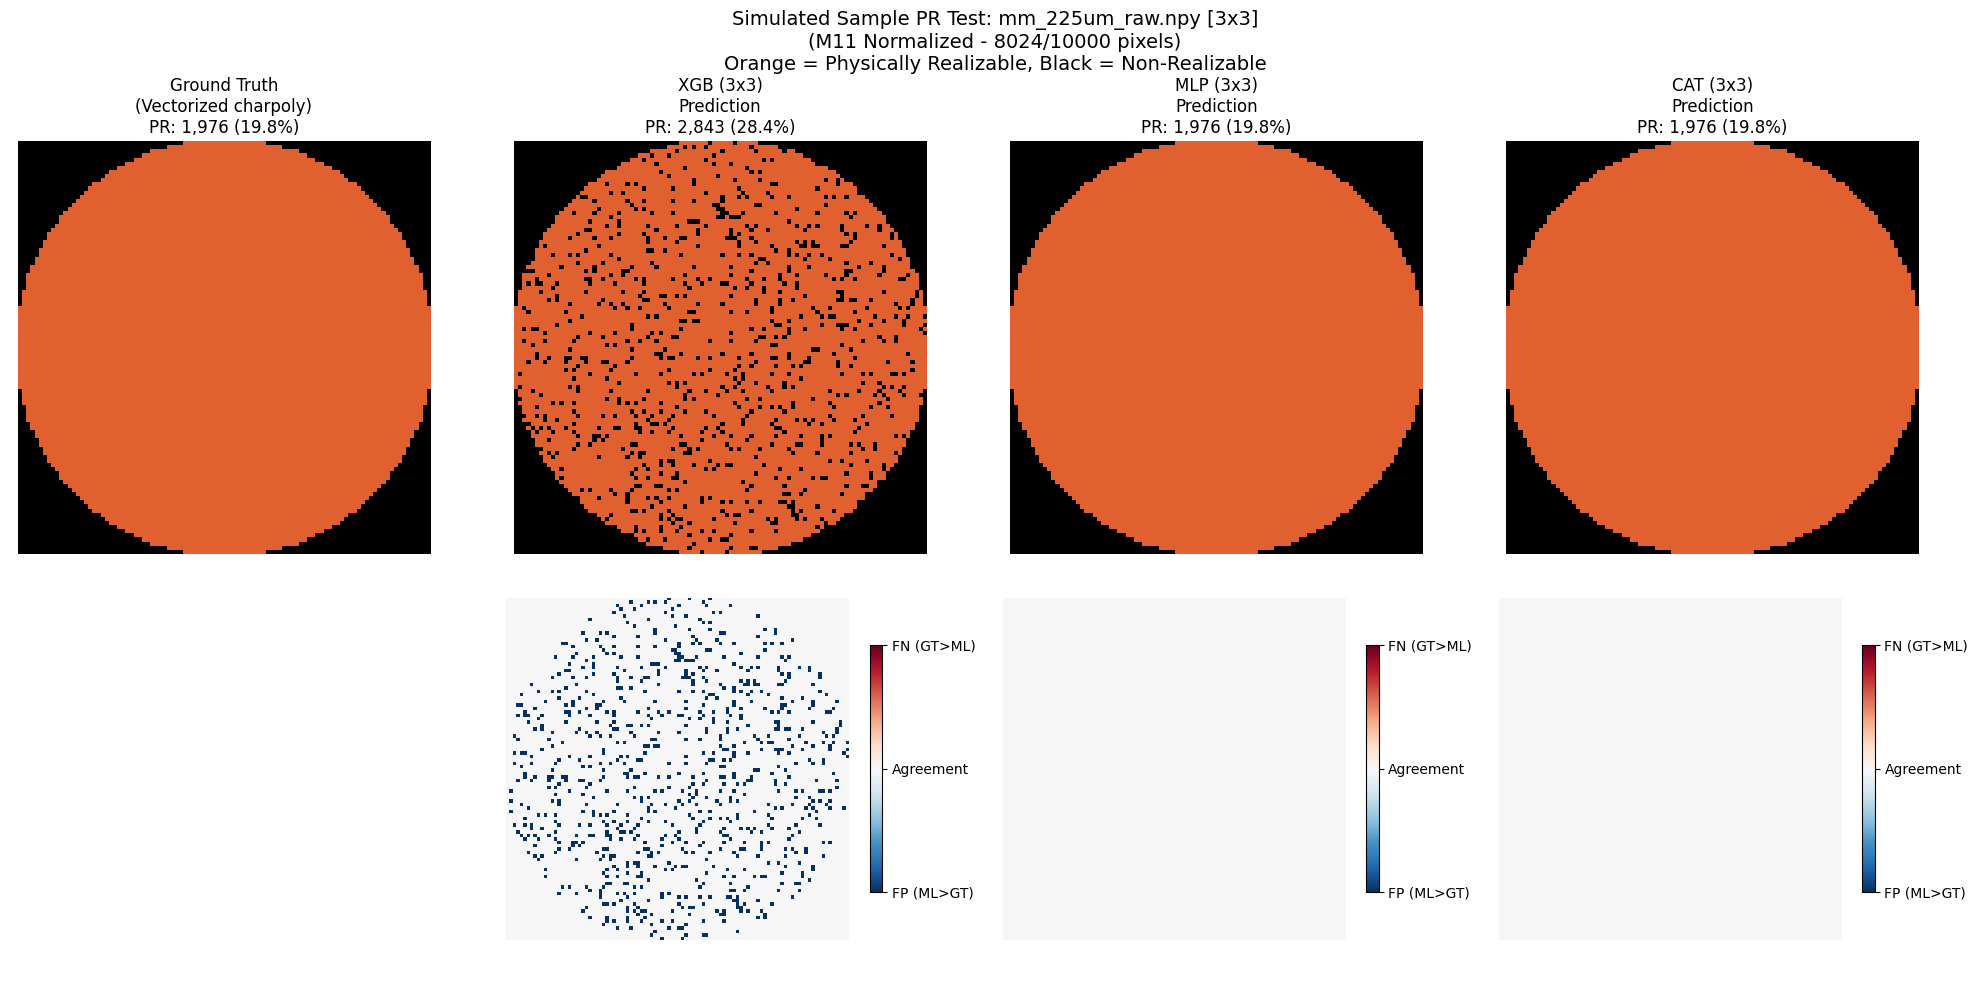


--- Scenario: 3x4 ---
Step 3.4: Testing XGB (3x4)
Making XGBoost predictions for 3x4 (threshold: 0.5)...
Using 12 Mueller matrix elements for XGBoost


XGB (3x4) completed in 25.75 ms (0.0257s)
ML PR pixels: 2,500 (25.00%)
Comparing XGB (3x4) with ground truth...
Comparison Results:
  Accuracy: 0.9476
  Precision: 0.7904
  Recall: 1.0000
  F1 Score: 0.8829
  Agreement: 0.9476 (94.76%)
  Jaccard Index: 0.7904
----------------------------------------
Step 3.5: Testing MLP (3x4)
Making MLP predictions for 3x4 (batch_size: 100000, threshold: 0.5)...
Using 12 Mueller matrix elements
MLP (3x4) completed in 2.83 ms (0.0028s)
ML PR pixels: 1,976 (19.76%)
Comparing MLP (3x4) with ground truth...
Comparison Results:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  Agreement: 1.0000 (100.00%)
  Jaccard Index: 1.0000
----------------------------------------
Step 3.6: Testing CAT (3x4)
Making CatBoost predictions for 3x4 (threshold: 0.5)...
Using 12 Mueller matrix elements
CAT (3x4) completed in 16.85 ms (0.0169s)
ML PR pixels: 2,122 (21.22%)
Comparing CAT (3x4) with ground truth...
Comparison Results:
  Accuracy: 0.985

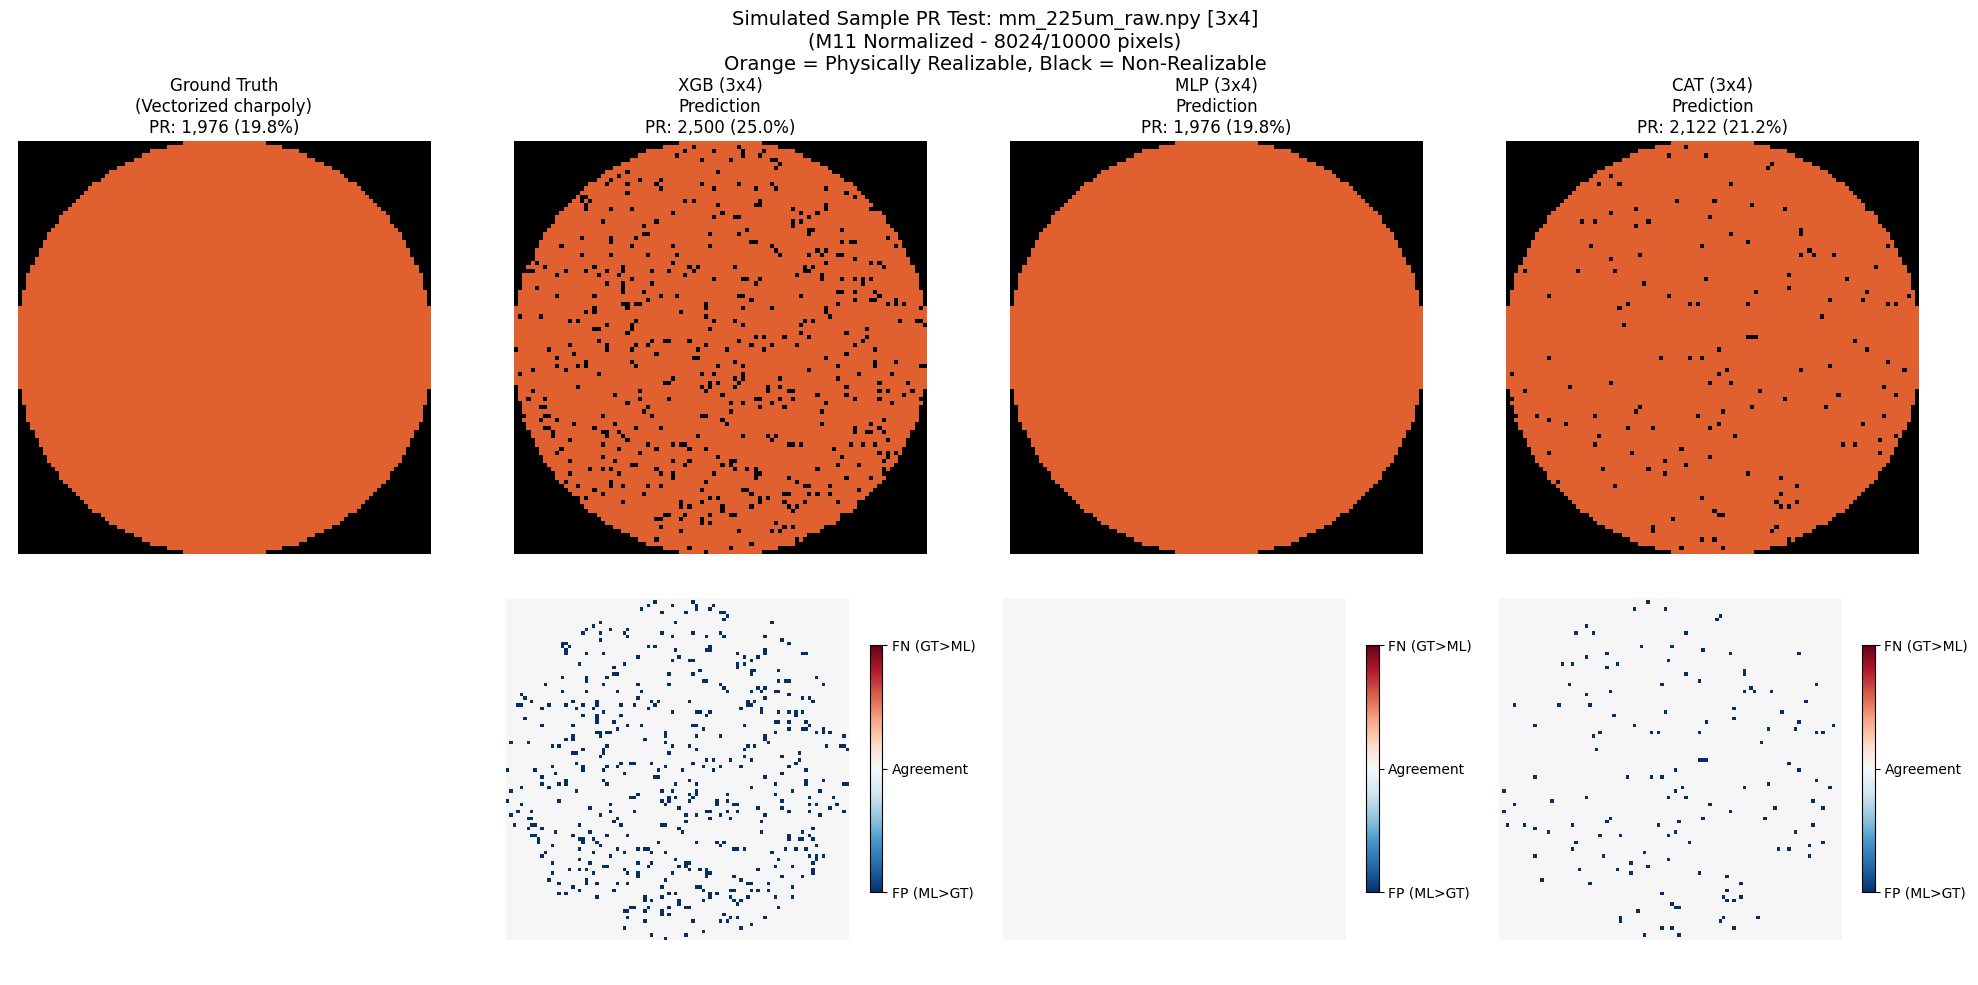


--- Scenario: 4x3 ---
Step 3.7: Testing XGB (4x3)
Making XGBoost predictions for 4x3 (threshold: 0.5)...
Using 12 Mueller matrix elements for XGBoost


XGB (4x3) completed in 25.84 ms (0.0258s)
ML PR pixels: 3,217 (32.17%)
Comparing XGB (4x3) with ground truth...
Comparison Results:
  Accuracy: 0.8759
  Precision: 0.6142
  Recall: 1.0000
  F1 Score: 0.7610
  Agreement: 0.8759 (87.59%)
  Jaccard Index: 0.6142
----------------------------------------
Step 3.8: Testing MLP (4x3)
Making MLP predictions for 4x3 (batch_size: 100000, threshold: 0.5)...
Using 12 Mueller matrix elements
MLP (4x3) completed in 2.63 ms (0.0026s)
ML PR pixels: 1,976 (19.76%)
Comparing MLP (4x3) with ground truth...
Comparison Results:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  Agreement: 1.0000 (100.00%)
  Jaccard Index: 1.0000
----------------------------------------
Step 3.9: Testing CAT (4x3)
Making CatBoost predictions for 4x3 (threshold: 0.5)...
Using 12 Mueller matrix elements
CAT (4x3) completed in 17.18 ms (0.0172s)
ML PR pixels: 2,019 (20.19%)
Comparing CAT (4x3) with ground truth...
Comparison Results:
  Accuracy: 0.995

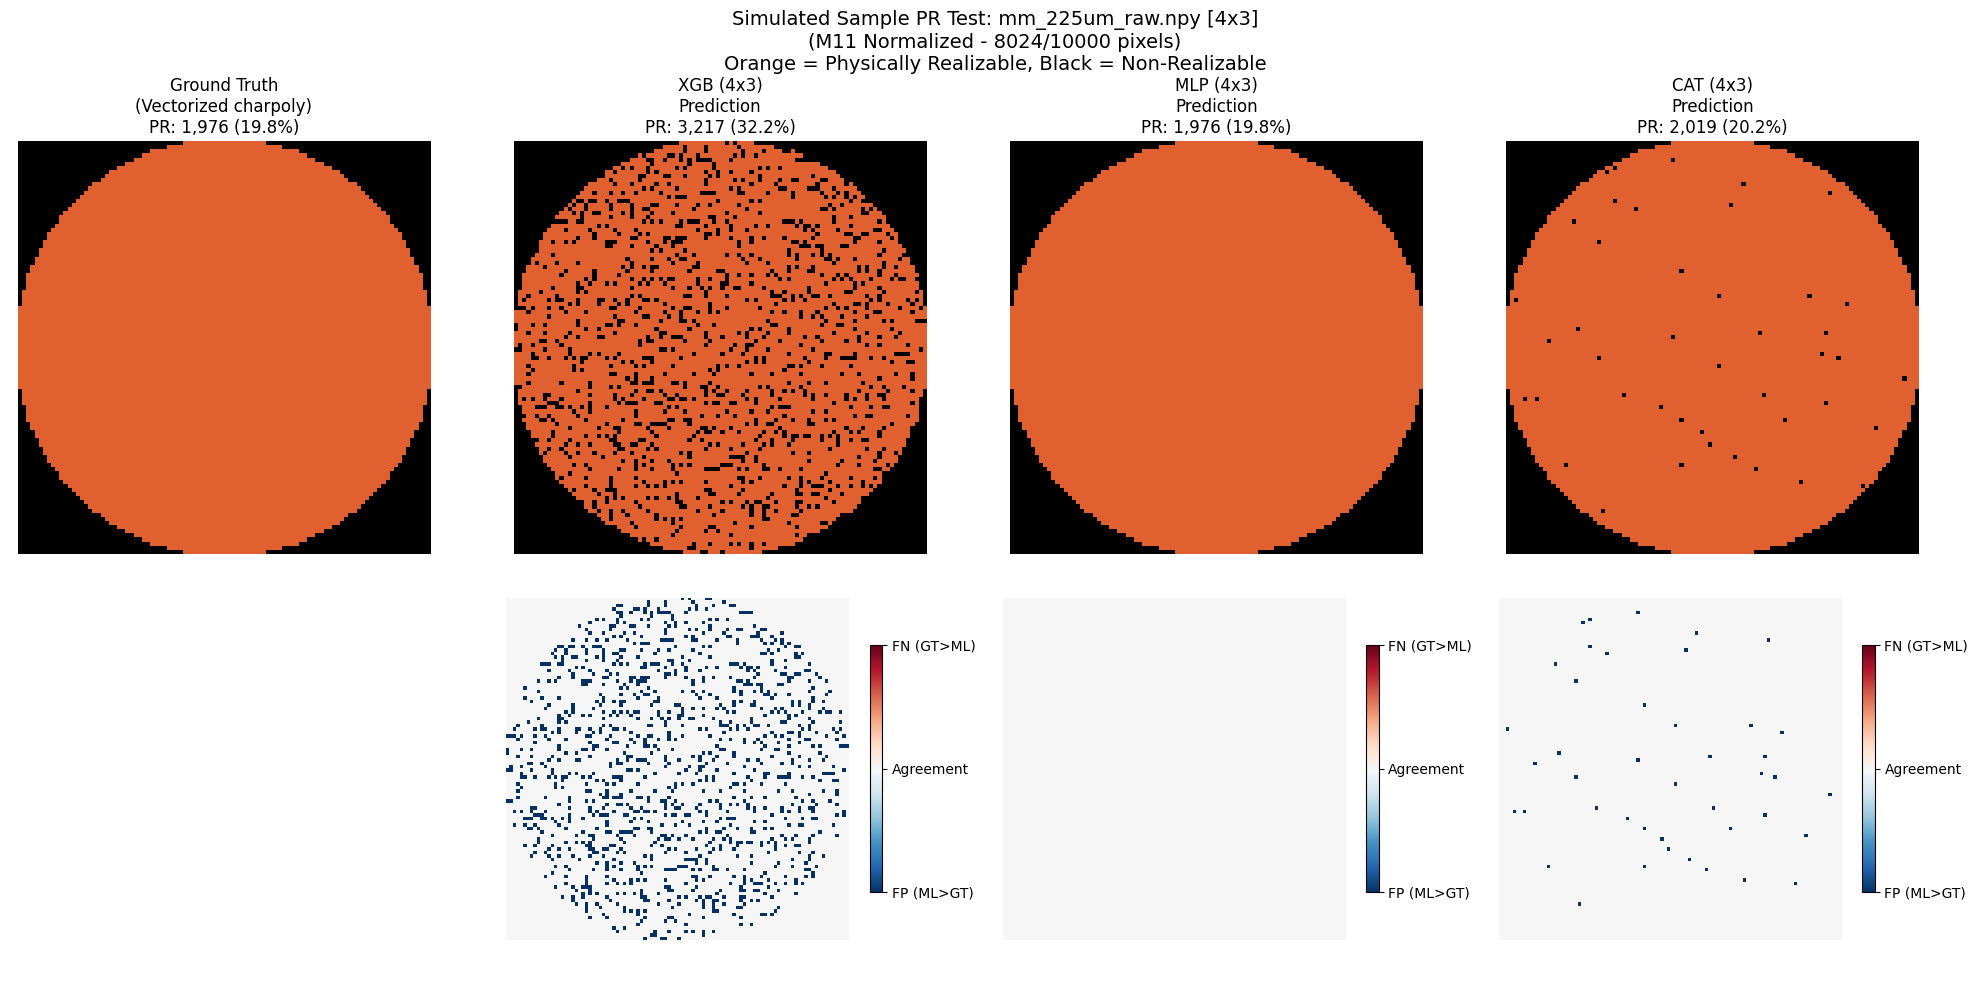


SIMULATED SAMPLE RESULTS SUMMARY: mm_225um_raw.npy
M11 Normalization Results:
  Total pixels: 10,000
  Successfully normalized: 8,024
  Original M11 mean: 0.000000
  Original M11 std: 0.000000
  Zero M11 values: 1976
  Negative M11 values: 0

Ground Truth (Vectorized charpoly):
  Time: 4.47 ms (0.004s)
  Speed: 2,236,115.5 samples/s
  PR Pixels: 1,976 (19.76%)

XGB (3x3):
  Time: 23.25 ms (0.023s)
  Speed: 430,193.9 samples/s
  Speed Ratio (ML/GT): 0.2x
  Time Ratio (GT/ML): 0.2x
  PR Pixels: 2,843 (28.43%)
  Accuracy: 0.9133
  F1 Score: 0.8201
  Precision: 0.6950
  Recall: 1.0000

MLP (3x3):
  Time: 11.48 ms (0.011s)
  Speed: 871,235.1 samples/s
  Speed Ratio (ML/GT): 0.4x
  Time Ratio (GT/ML): 0.4x
  PR Pixels: 1,976 (19.76%)
  Accuracy: 1.0000
  F1 Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000

CAT (3x3):
  Time: 19.05 ms (0.019s)
  Speed: 525,024.0 samples/s
  Speed Ratio (ML/GT): 0.2x
  Time Ratio (GT/ML): 0.2x
  PR Pixels: 1,976 (19.76%)
  Accuracy: 1.0000
  F1 Score: 1.000

Saved PDF successfully to /Users/chaechae/Desktop/EP_Code/partialPr/results/figures/simulated/Normalized_Mueller_mm_250um_raw.npy_sim.pdf


Saved PDF successfully to /Users/chaechae/Desktop/EP_Code/partialPr/results/figures/simulated/NoFilter_Mueller_mm_250um_raw.npy_sim.pdf
Step 2: Ground Truth PR Test
Computing ground truth PR test using vectorized charpoly (batch size: 100,000)...
Ground truth PR test completed in 4.92 ms (0.005s)
GT PR pixels: 1,976 (19.76%)
--------------------------------------------------------------------------------

--- Scenario: 3x3 ---
Step 3.1: Testing XGB (3x3)
Making XGBoost predictions for 3x3 (threshold: 0.5)...
Using 9 Mueller matrix elements for XGBoost


XGB (3x3) completed in 23.18 ms (0.0232s)
ML PR pixels: 2,859 (28.59%)
Comparing XGB (3x3) with ground truth...
Comparison Results:
  Accuracy: 0.9117
  Precision: 0.6912
  Recall: 1.0000
  F1 Score: 0.8174
  Agreement: 0.9117 (91.17%)
  Jaccard Index: 0.6912
----------------------------------------
Step 3.2: Testing MLP (3x3)
Making MLP predictions for 3x3 (batch_size: 100000, threshold: 0.5)...
Using 9 Mueller matrix elements
MLP (3x3) completed in 2.78 ms (0.0028s)
ML PR pixels: 1,976 (19.76%)
Comparing MLP (3x3) with ground truth...
Comparison Results:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  Agreement: 1.0000 (100.00%)
  Jaccard Index: 1.0000
----------------------------------------
Step 3.3: Testing CAT (3x3)
Making CatBoost predictions for 3x3 (threshold: 0.5)...
Using 9 Mueller matrix elements
CAT (3x3) completed in 13.43 ms (0.0134s)
ML PR pixels: 1,976 (19.76%)
Comparing CAT (3x3) with ground truth...
Comparison Results:
  Accuracy: 1.0000


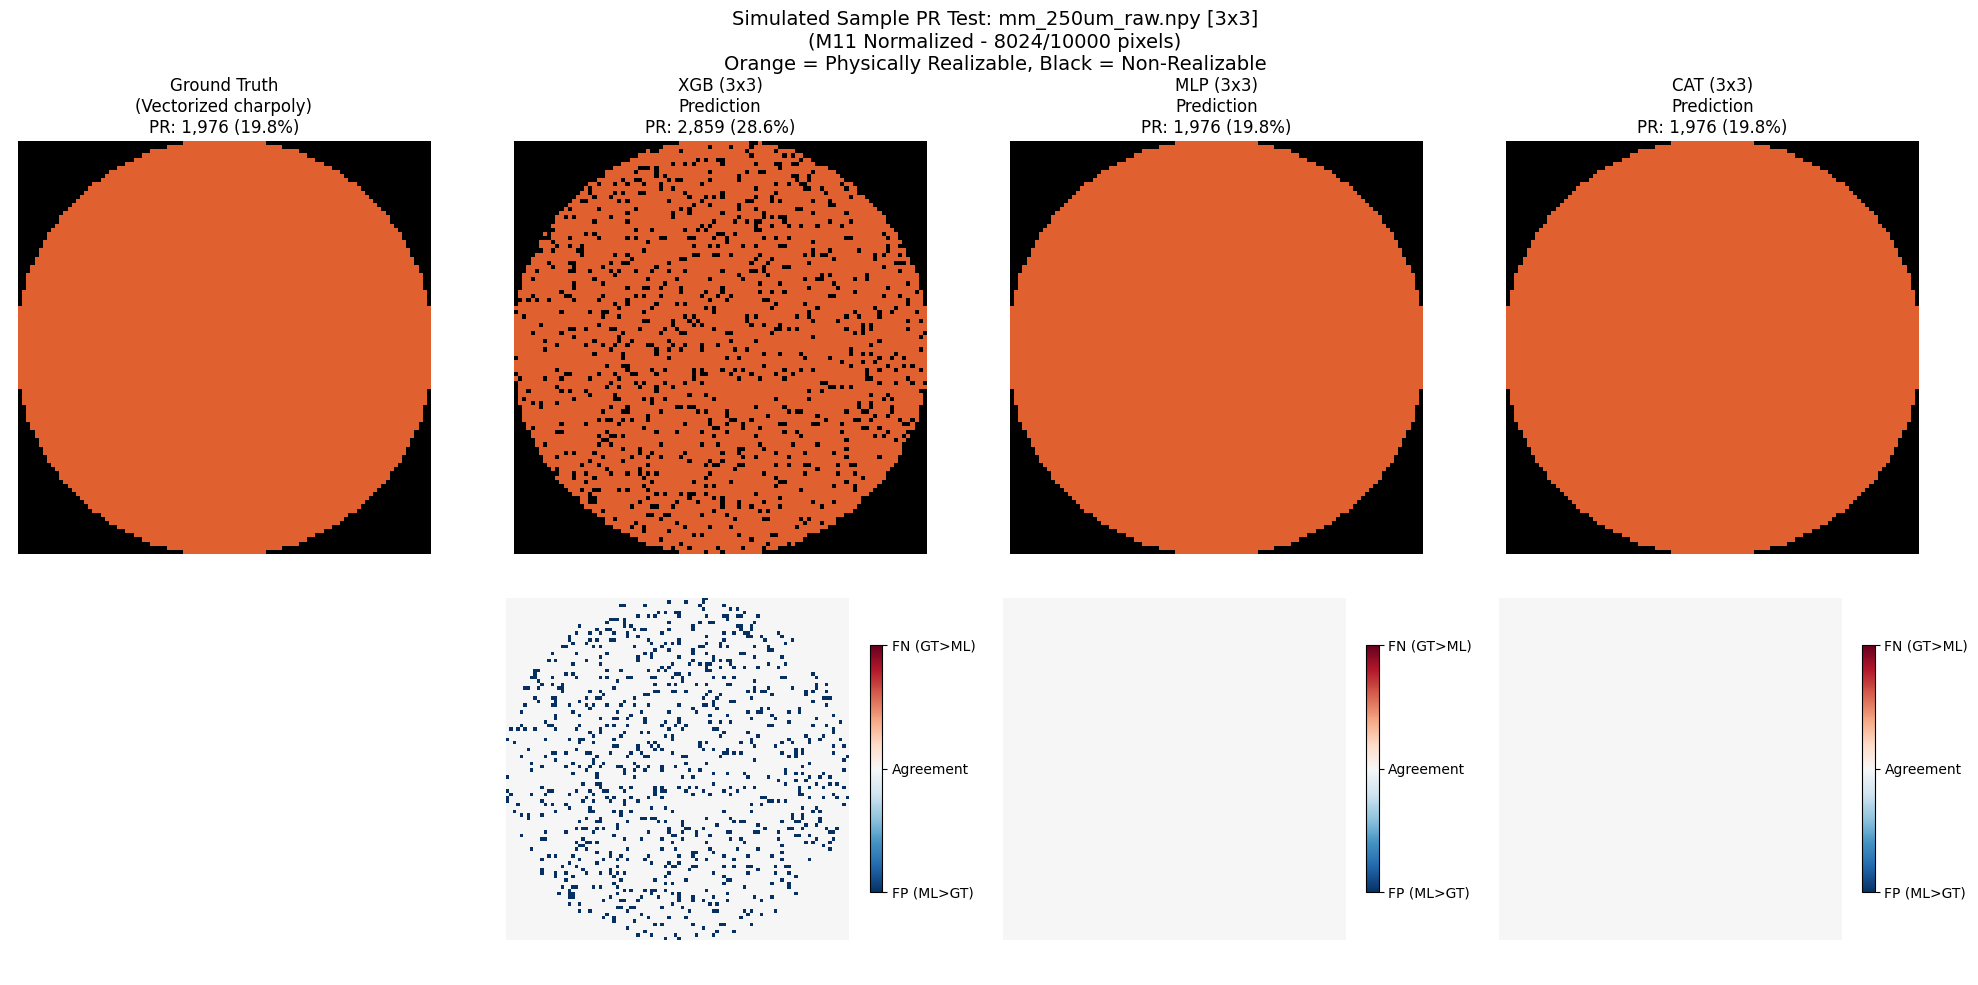


--- Scenario: 3x4 ---
Step 3.4: Testing XGB (3x4)
Making XGBoost predictions for 3x4 (threshold: 0.5)...
Using 12 Mueller matrix elements for XGBoost


XGB (3x4) completed in 28.68 ms (0.0287s)
ML PR pixels: 2,520 (25.20%)
Comparing XGB (3x4) with ground truth...
Comparison Results:
  Accuracy: 0.9456
  Precision: 0.7841
  Recall: 1.0000
  F1 Score: 0.8790
  Agreement: 0.9456 (94.56%)
  Jaccard Index: 0.7841
----------------------------------------
Step 3.5: Testing MLP (3x4)
Making MLP predictions for 3x4 (batch_size: 100000, threshold: 0.5)...
Using 12 Mueller matrix elements
MLP (3x4) completed in 2.64 ms (0.0026s)
ML PR pixels: 1,976 (19.76%)
Comparing MLP (3x4) with ground truth...
Comparison Results:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  Agreement: 1.0000 (100.00%)
  Jaccard Index: 1.0000
----------------------------------------
Step 3.6: Testing CAT (3x4)
Making CatBoost predictions for 3x4 (threshold: 0.5)...
Using 12 Mueller matrix elements
CAT (3x4) completed in 17.28 ms (0.0173s)
ML PR pixels: 2,123 (21.23%)
Comparing CAT (3x4) with ground truth...
Comparison Results:
  Accuracy: 0.985

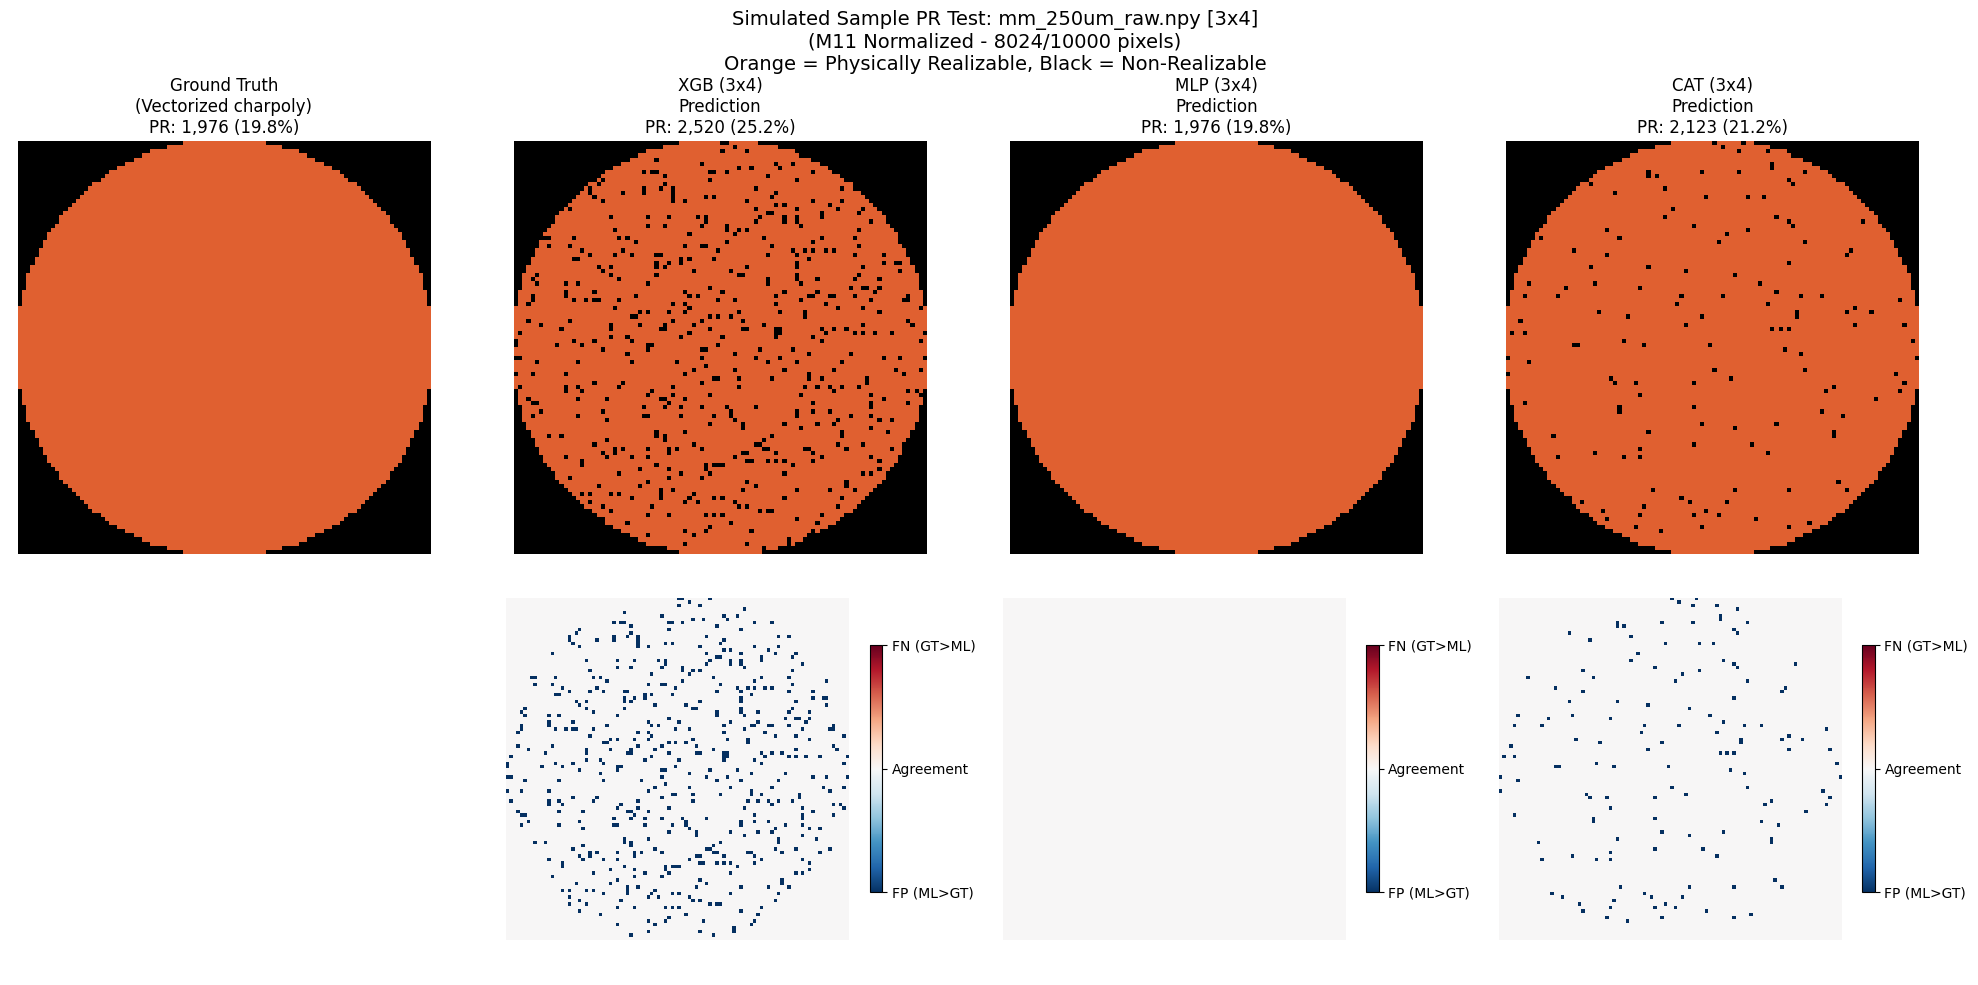


--- Scenario: 4x3 ---
Step 3.7: Testing XGB (4x3)
Making XGBoost predictions for 4x3 (threshold: 0.5)...
Using 12 Mueller matrix elements for XGBoost


XGB (4x3) completed in 27.88 ms (0.0279s)
ML PR pixels: 3,187 (31.87%)
Comparing XGB (4x3) with ground truth...
Comparison Results:
  Accuracy: 0.8789
  Precision: 0.6200
  Recall: 1.0000
  F1 Score: 0.7654
  Agreement: 0.8789 (87.89%)
  Jaccard Index: 0.6200
----------------------------------------
Step 3.8: Testing MLP (4x3)
Making MLP predictions for 4x3 (batch_size: 100000, threshold: 0.5)...
Using 12 Mueller matrix elements
MLP (4x3) completed in 2.84 ms (0.0028s)
ML PR pixels: 1,976 (19.76%)
Comparing MLP (4x3) with ground truth...
Comparison Results:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  Agreement: 1.0000 (100.00%)
  Jaccard Index: 1.0000
----------------------------------------
Step 3.9: Testing CAT (4x3)
Making CatBoost predictions for 4x3 (threshold: 0.5)...
Using 12 Mueller matrix elements
CAT (4x3) completed in 17.53 ms (0.0175s)
ML PR pixels: 2,015 (20.15%)
Comparing CAT (4x3) with ground truth...
Comparison Results:
  Accuracy: 0.996

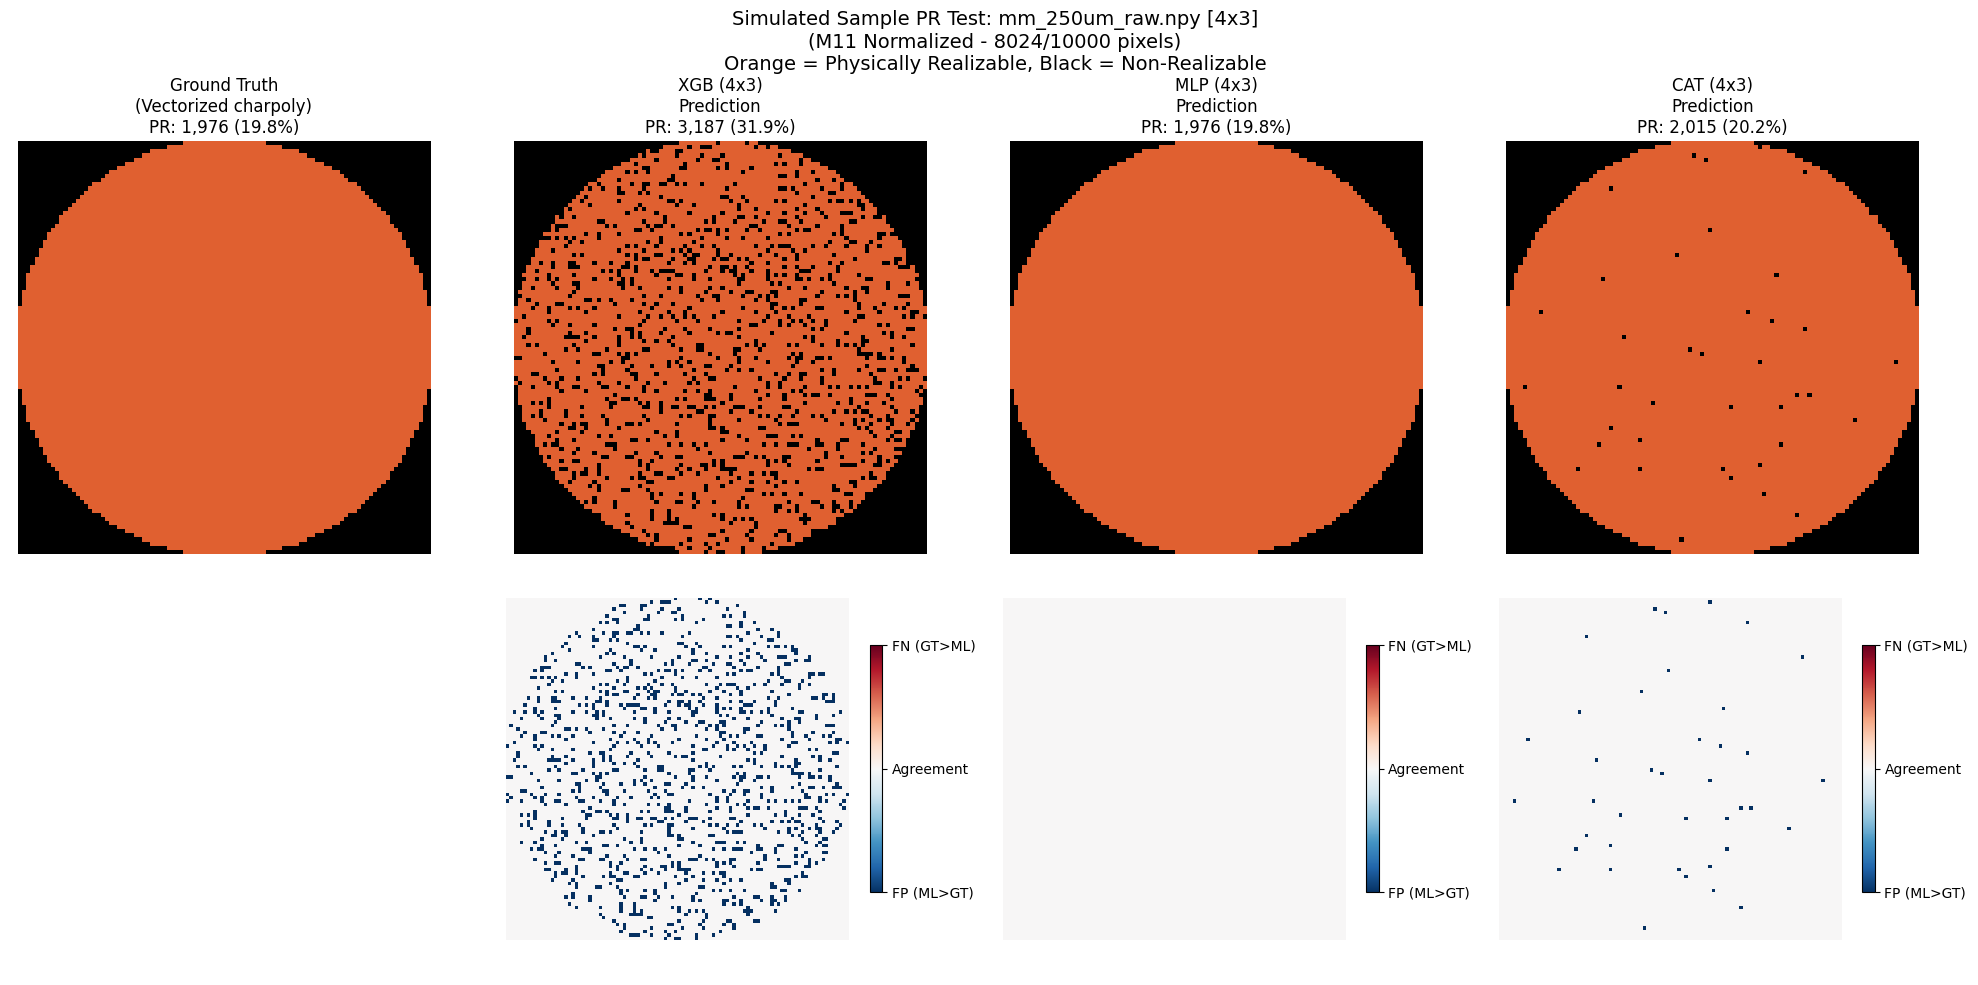


SIMULATED SAMPLE RESULTS SUMMARY: mm_250um_raw.npy
M11 Normalization Results:
  Total pixels: 10,000
  Successfully normalized: 8,024
  Original M11 mean: 0.000000
  Original M11 std: 0.000000
  Zero M11 values: 1976
  Negative M11 values: 0

Ground Truth (Vectorized charpoly):
  Time: 4.92 ms (0.005s)
  Speed: 2,032,520.3 samples/s
  PR Pixels: 1,976 (19.76%)

XGB (3x3):
  Time: 23.18 ms (0.023s)
  Speed: 431,378.5 samples/s
  Speed Ratio (ML/GT): 0.2x
  Time Ratio (GT/ML): 0.2x
  PR Pixels: 2,859 (28.59%)
  Accuracy: 0.9117
  F1 Score: 0.8174
  Precision: 0.6912
  Recall: 1.0000

MLP (3x3):
  Time: 2.78 ms (0.003s)
  Speed: 3,592,922.0 samples/s
  Speed Ratio (ML/GT): 1.8x
  Time Ratio (GT/ML): 1.8x
  PR Pixels: 1,976 (19.76%)
  Accuracy: 1.0000
  F1 Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000

CAT (3x3):
  Time: 13.43 ms (0.013s)
  Speed: 744,825.8 samples/s
  Speed Ratio (ML/GT): 0.4x
  Time Ratio (GT/ML): 0.4x
  PR Pixels: 1,976 (19.76%)
  Accuracy: 1.0000
  F1 Score: 1.00

Saved PDF successfully to /Users/chaechae/Desktop/EP_Code/partialPr/results/figures/simulated/NoFilter_Mueller_mm_300um_raw.npy_sim.pdf
Step 2: Ground Truth PR Test
Computing ground truth PR test using vectorized charpoly (batch size: 100,000)...
Ground truth PR test completed in 5.38 ms (0.005s)
GT PR pixels: 1,976 (19.76%)
--------------------------------------------------------------------------------

--- Scenario: 3x3 ---
Step 3.1: Testing XGB (3x3)
Making XGBoost predictions for 3x3 (threshold: 0.5)...
Using 9 Mueller matrix elements for XGBoost


XGB (3x3) completed in 21.20 ms (0.0212s)
ML PR pixels: 2,847 (28.47%)
Comparing XGB (3x3) with ground truth...
Comparison Results:
  Accuracy: 0.9129
  Precision: 0.6941
  Recall: 1.0000
  F1 Score: 0.8194
  Agreement: 0.9129 (91.29%)
  Jaccard Index: 0.6941
----------------------------------------
Step 3.2: Testing MLP (3x3)
Making MLP predictions for 3x3 (batch_size: 100000, threshold: 0.5)...
Using 9 Mueller matrix elements
MLP (3x3) completed in 3.00 ms (0.0030s)
ML PR pixels: 1,976 (19.76%)
Comparing MLP (3x3) with ground truth...
Comparison Results:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  Agreement: 1.0000 (100.00%)
  Jaccard Index: 1.0000
----------------------------------------
Step 3.3: Testing CAT (3x3)
Making CatBoost predictions for 3x3 (threshold: 0.5)...
Using 9 Mueller matrix elements
CAT (3x3) completed in 13.34 ms (0.0133s)
ML PR pixels: 1,976 (19.76%)
Comparing CAT (3x3) with ground truth...
Comparison Results:
  Accuracy: 1.0000


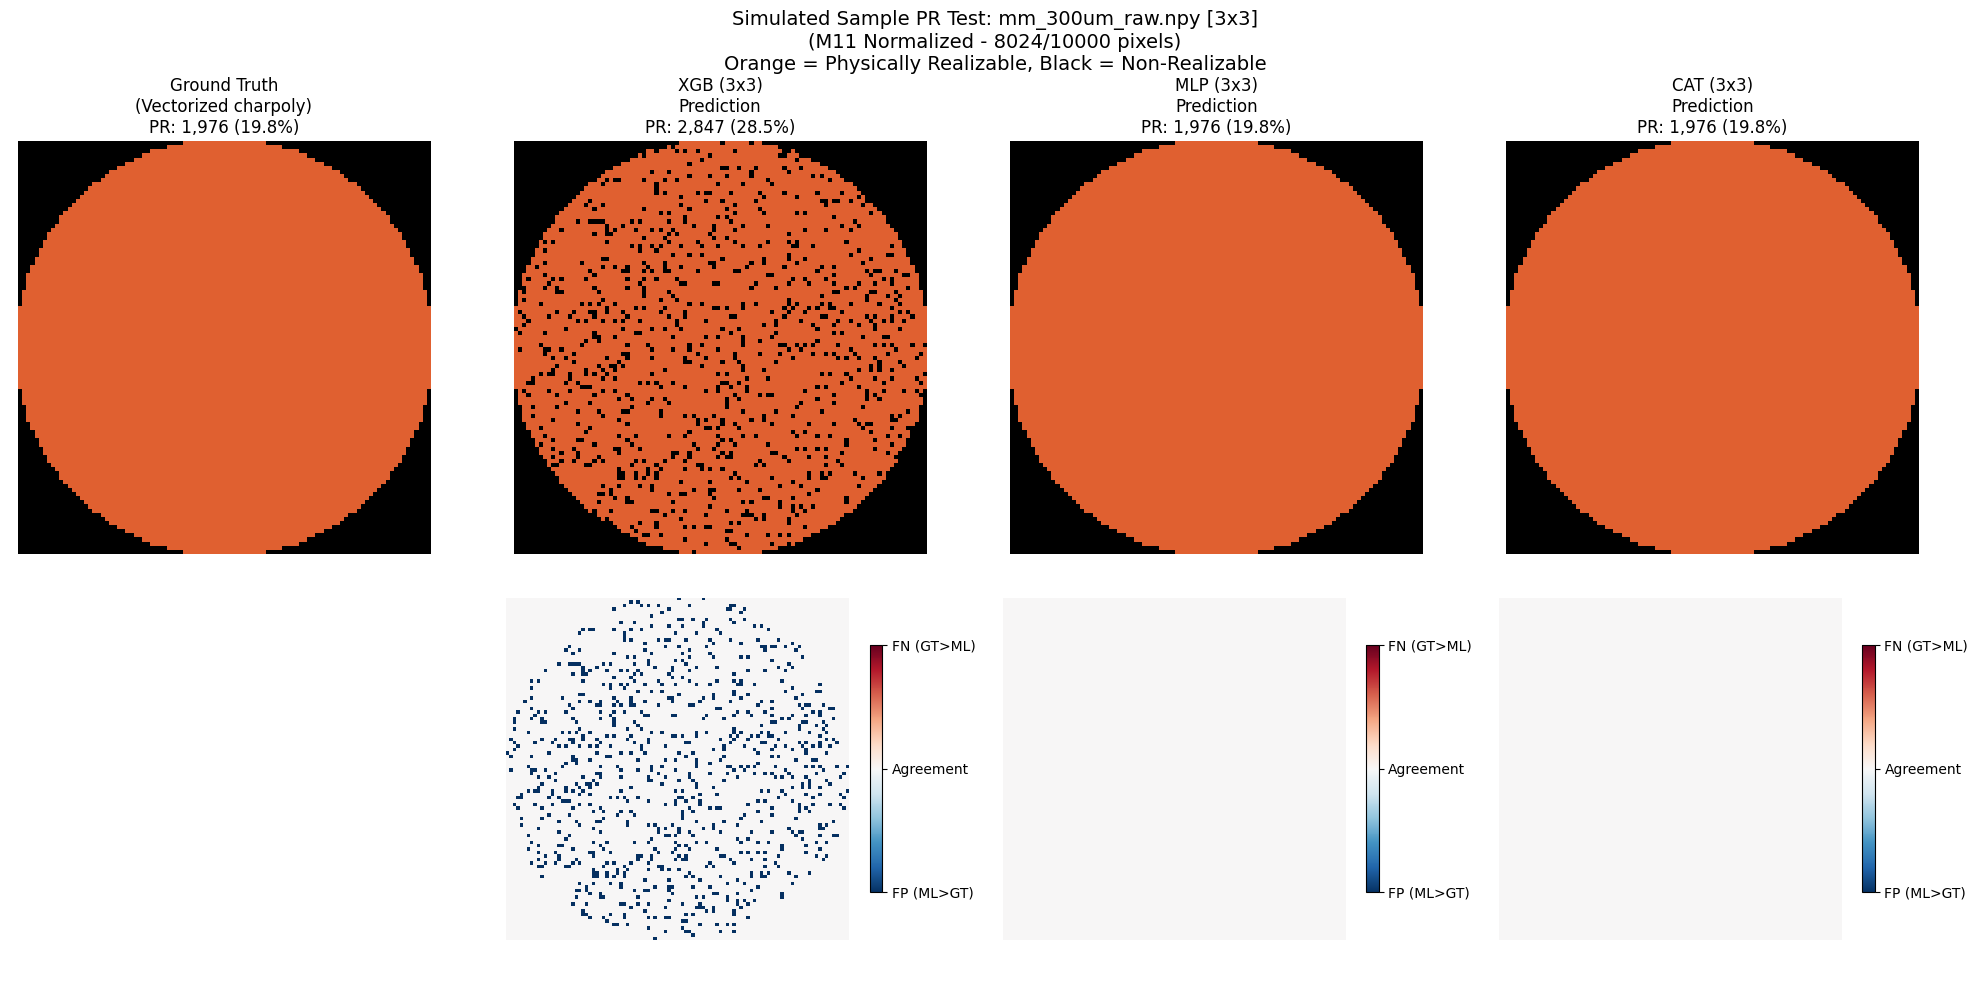


--- Scenario: 3x4 ---
Step 3.4: Testing XGB (3x4)
Making XGBoost predictions for 3x4 (threshold: 0.5)...
Using 12 Mueller matrix elements for XGBoost


XGB (3x4) completed in 33.31 ms (0.0333s)
ML PR pixels: 2,512 (25.12%)
Comparing XGB (3x4) with ground truth...
Comparison Results:
  Accuracy: 0.9464
  Precision: 0.7866
  Recall: 1.0000
  F1 Score: 0.8806
  Agreement: 0.9464 (94.64%)
  Jaccard Index: 0.7866
----------------------------------------
Step 3.5: Testing MLP (3x4)
Making MLP predictions for 3x4 (batch_size: 100000, threshold: 0.5)...
Using 12 Mueller matrix elements
MLP (3x4) completed in 3.13 ms (0.0031s)
ML PR pixels: 1,976 (19.76%)
Comparing MLP (3x4) with ground truth...
Comparison Results:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  Agreement: 1.0000 (100.00%)
  Jaccard Index: 1.0000
----------------------------------------
Step 3.6: Testing CAT (3x4)
Making CatBoost predictions for 3x4 (threshold: 0.5)...
Using 12 Mueller matrix elements
CAT (3x4) completed in 17.28 ms (0.0173s)
ML PR pixels: 2,134 (21.34%)
Comparing CAT (3x4) with ground truth...
Comparison Results:
  Accuracy: 0.984

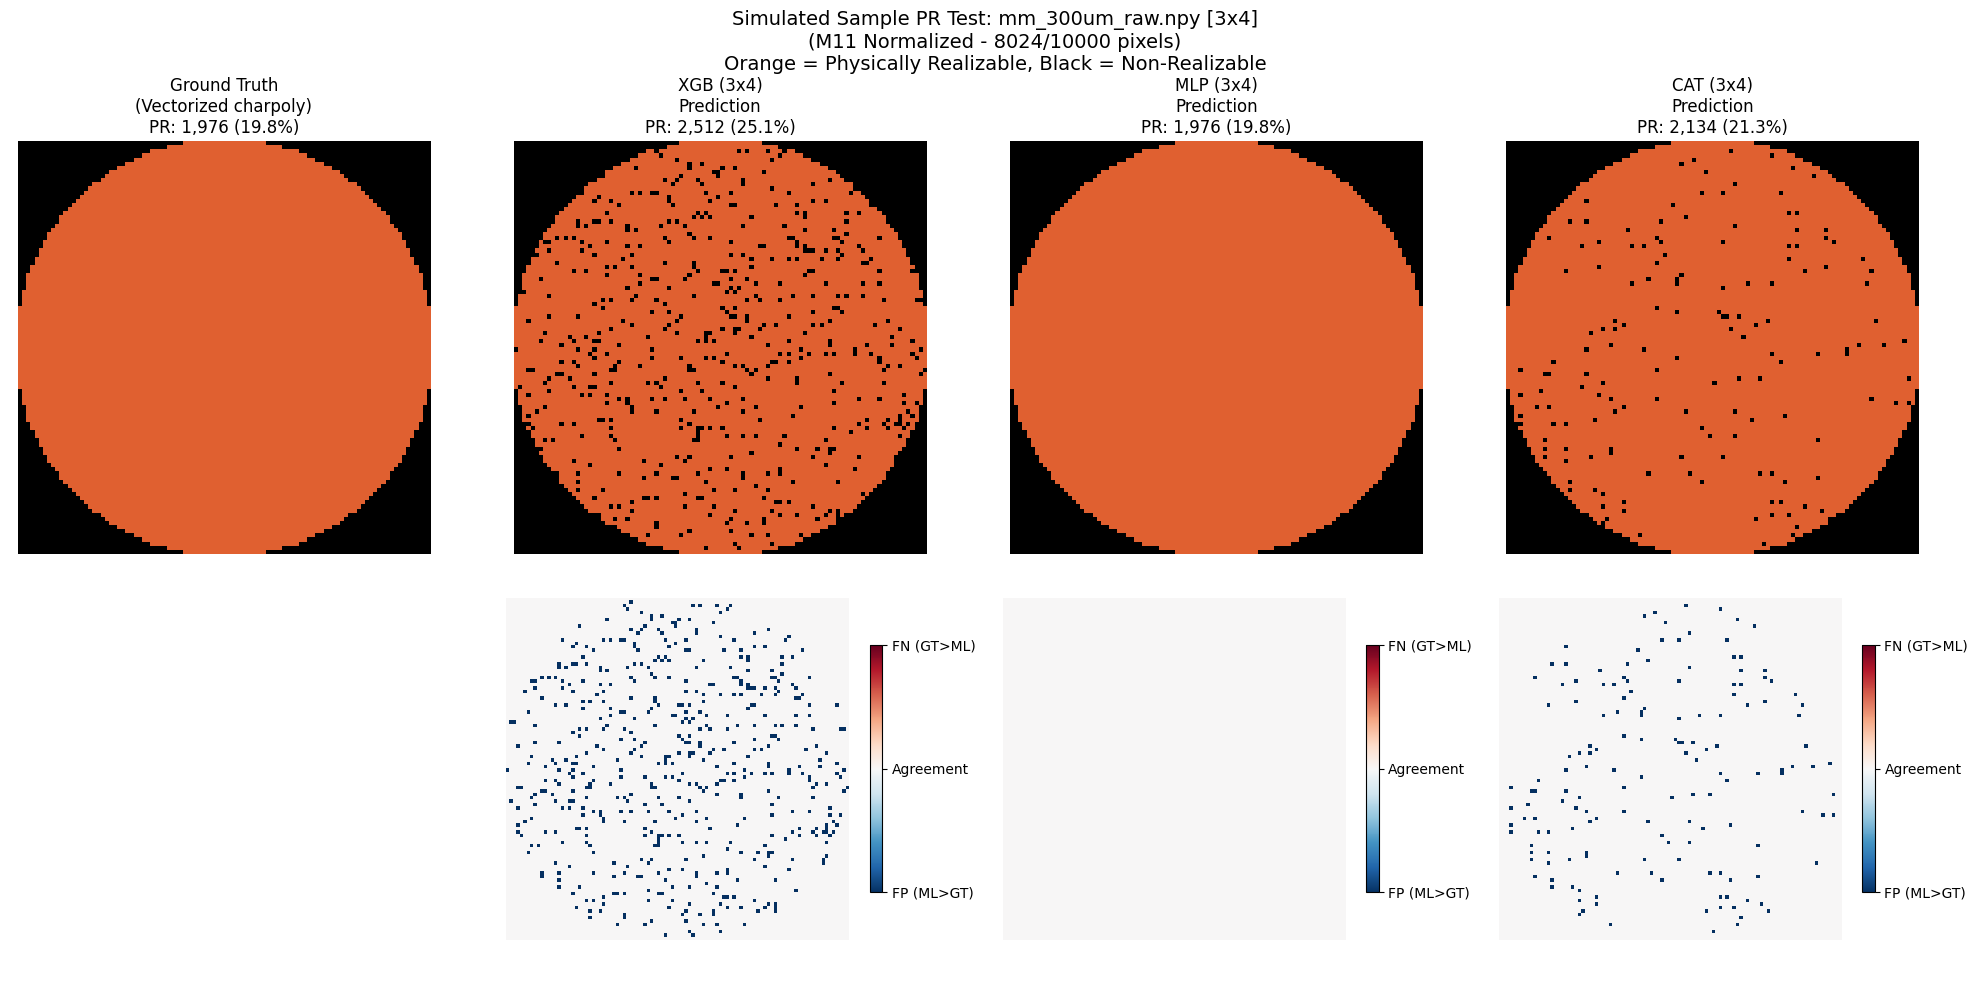


--- Scenario: 4x3 ---
Step 3.7: Testing XGB (4x3)
Making XGBoost predictions for 4x3 (threshold: 0.5)...
Using 12 Mueller matrix elements for XGBoost


XGB (4x3) completed in 29.80 ms (0.0298s)
ML PR pixels: 3,210 (32.10%)
Comparing XGB (4x3) with ground truth...
Comparison Results:
  Accuracy: 0.8766
  Precision: 0.6156
  Recall: 1.0000
  F1 Score: 0.7621
  Agreement: 0.8766 (87.66%)
  Jaccard Index: 0.6156
----------------------------------------
Step 3.8: Testing MLP (4x3)
Making MLP predictions for 4x3 (batch_size: 100000, threshold: 0.5)...
Using 12 Mueller matrix elements
MLP (4x3) completed in 2.75 ms (0.0028s)
ML PR pixels: 1,976 (19.76%)
Comparing MLP (4x3) with ground truth...
Comparison Results:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  Agreement: 1.0000 (100.00%)
  Jaccard Index: 1.0000
----------------------------------------
Step 3.9: Testing CAT (4x3)
Making CatBoost predictions for 4x3 (threshold: 0.5)...
Using 12 Mueller matrix elements
CAT (4x3) completed in 17.39 ms (0.0174s)
ML PR pixels: 2,011 (20.11%)
Comparing CAT (4x3) with ground truth...
Comparison Results:
  Accuracy: 0.996

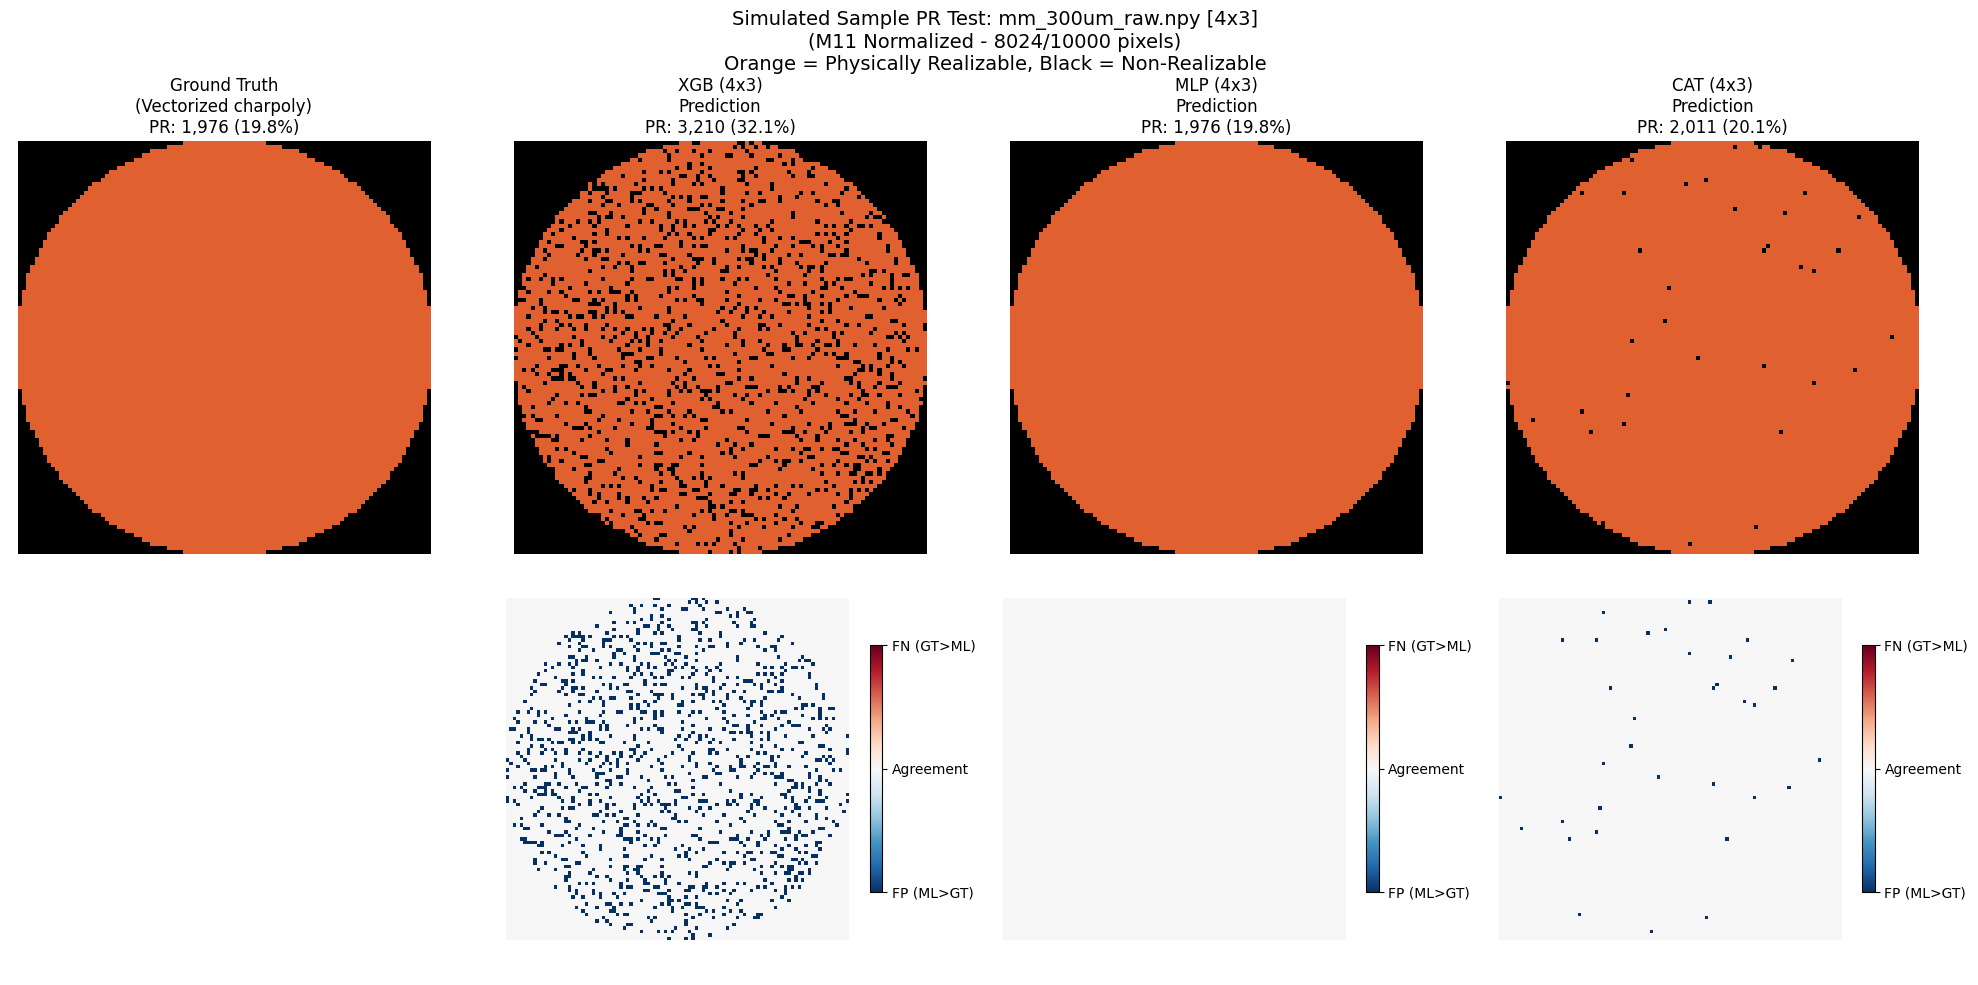


SIMULATED SAMPLE RESULTS SUMMARY: mm_300um_raw.npy
M11 Normalization Results:
  Total pixels: 10,000
  Successfully normalized: 8,024
  Original M11 mean: 0.000000
  Original M11 std: 0.000000
  Zero M11 values: 1976
  Negative M11 values: 0

Ground Truth (Vectorized charpoly):
  Time: 5.38 ms (0.005s)
  Speed: 1,857,355.1 samples/s
  PR Pixels: 1,976 (19.76%)

XGB (3x3):
  Time: 21.20 ms (0.021s)
  Speed: 471,808.5 samples/s
  Speed Ratio (ML/GT): 0.3x
  Time Ratio (GT/ML): 0.3x
  PR Pixels: 2,847 (28.47%)
  Accuracy: 0.9129
  F1 Score: 0.8194
  Precision: 0.6941
  Recall: 1.0000

MLP (3x3):
  Time: 3.00 ms (0.003s)
  Speed: 3,337,968.6 samples/s
  Speed Ratio (ML/GT): 1.8x
  Time Ratio (GT/ML): 1.8x
  PR Pixels: 1,976 (19.76%)
  Accuracy: 1.0000
  F1 Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000

CAT (3x3):
  Time: 13.34 ms (0.013s)
  Speed: 749,456.6 samples/s
  Speed Ratio (ML/GT): 0.4x
  Time Ratio (GT/ML): 0.4x
  PR Pixels: 1,976 (19.76%)
  Accuracy: 1.0000
  F1 Score: 1.00

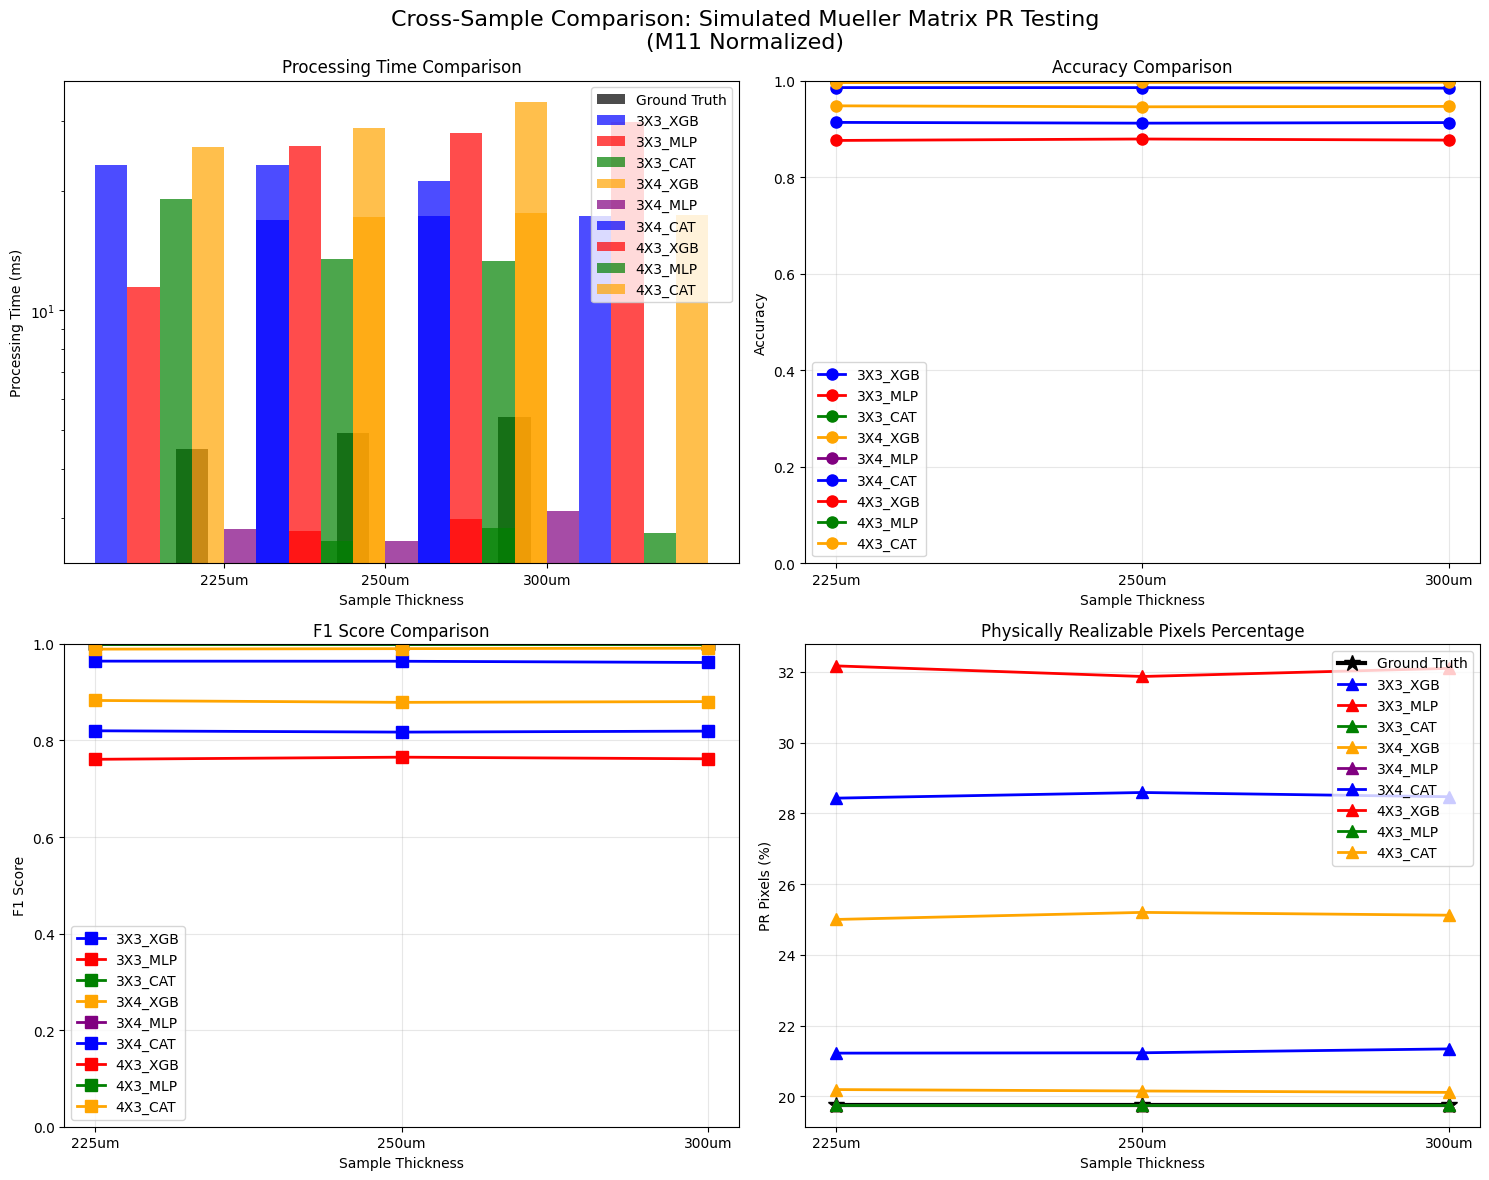


✓ Successfully completed testing 3 samples!
All results saved in 'all_results' variable for further analysis.


In [14]:
if __name__ == "__main__":
    # Configuration
    SIMULATED_SAMPLES = ['mm_225um_raw.npy', 'mm_250um_raw.npy', 'mm_300um_raw.npy']
    SCENARIOS_TO_TEST = ['3x3', '3x4', '4x3']
    MODELS_TO_TEST = ['xgb', 'mlp', 'cat']

    print("SIMULATED MUELLER MATRIX PR TEST WITH M11 NORMALIZATION")
    print("=" * 80)
    print("Testing simulated samples with proper M11 normalization")
    print(f"Samples: {', '.join(SIMULATED_SAMPLES)}")
    print(f"Scenarios: {', '.join(SCENARIOS_TO_TEST)}")
    print(f"Models: {', '.join([m.upper() for m in MODELS_TO_TEST])}")
    print("=" * 80)

    # Run comprehensive test on all simulated samples and all scenarios
    all_results = run_all_simulated_samples_test(
        sample_names=SIMULATED_SAMPLES,
        models=MODELS_TO_TEST,
        scenarios=SCENARIOS_TO_TEST,
        gt_batch_size=100000,    # Large batch for ground truth
        ml_batch_size=100000,    # Large batch for MLP
        threshold=0.5,
    )

    if all_results:
        print(f"\n✓ Successfully completed testing {len(all_results)} samples!")
        print("All results saved in 'all_results' variable for further analysis.")
    else:
        print("✗ No samples were successfully processed.")
